In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
from linearmodels.panel import PanelOLS


sns.set_theme(style="whitegrid")

In [94]:
pd.set_option('display.max_rows', None)

In [95]:
DATA_DIR = Path(r'C:\Users\indra\Desktop\Thesis\Final project for thesis\Data')

df = pd.read_csv(DATA_DIR / 'data_final.csv')
print(f'Loaded {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded 4,032 rows x 16 columns


In [96]:
df.head(10)

,Country,ISO3,Year,Consumption_Emissions,Production_Emissions,GDP_per_capita,Trade_Openness,Population,annex_b,first_treat,post,rel_year,first_treat_2008,post_2008,rel_year_2008,country_id
0,Albania,ALB,1990,5.573464,5.520602,5560.833935,39.436963,3277966,0,0,0,NaN,0,0,NaN,0
1,Albania,ALB,1991,4.616082,4.290226,4027.888807,36.070520,3282602,0,0,0,NaN,0,0,NaN,0
2,Albania,ALB,1992,2.924931,2.517116,3761.139808,108.785472,3282501,0,0,0,NaN,0,0,NaN,0
3,Albania,ALB,1993,2.674815,2.337999,4145.902505,80.518333,3277825,0,0,0,NaN,0,0,NaN,0
4,Albania,ALB,1994,2.365348,1.923806,4517.780079,53.102585,3269410,0,0,0,NaN,0,0,NaN,0
5,Albania,ALB,1995,2.523127,2.089065,5151.375962,40.138699,3258567,0,0,0,NaN,0,0,NaN,0
6,Albania,ALB,1996,2.894911,2.017508,5563.770078,44.411782,3245678,0,0,0,NaN,0,0,NaN,0
7,Albania,ALB,1997,2.192159,1.543009,4942.983500,44.729378,3229660,0,0,0,NaN,0,0,NaN,0
8,Albania,ALB,1998,2.433192,1.754709,5387.545887,47.130627,3210133,0,0,0,NaN,0,0,NaN,0
9,Albania,ALB,1999,3.707882,2.986196,6085.983397,49.895418,3188595,0,0,0,NaN,0,0,NaN,0


**First look.** The file carries three groups of columns: identifiers (`Country`, `ISO3`, `Year`); the two emissions totals in Mt CO₂ (`Consumption_Emissions`, `Production_Emissions`) plus `GDP_per_capita` (PPP, constant 2021 $), `Trade_Openness` (% of GDP) and `Population`; and the DiD treatment coding (`annex_b`, `first_treat`, `post`, `rel_year`, the 2008-timing variants, `country_id`).

*Corrected:* the leakage measures `transfer` and `gap_share` are **not** in this file — they are derived in Section 2. An earlier note here listed them among the loaded columns.

Albania is `annex_b = 0`, so `first_treat` is 0 and `rel_year` is `NaN` — correct for a never-treated unit, not a missing value.

## 1. Data Quality Checks

Shape, dtypes, missingness, duplicate keys and panel balance before anything else — every downstream statistic depends on this being clean.

In [97]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nCountries:", df['Country'].nunique(), "| Years:", df['Year'].min(), "-", df['Year'].max())

Shape: (4032, 16)

Dtypes:
 Country                      str
ISO3                         str
Year                       int64
Consumption_Emissions    float64
Production_Emissions     float64
GDP_per_capita           float64
Trade_Openness           float64
Population                 int64
annex_b                    int64
first_treat                int64
post                       int64
rel_year                 float64
first_treat_2008           int64
post_2008                  int64
rel_year_2008            float64
country_id                 int64
dtype: object

Missing values:
 Country                     0
ISO3                        0
Year                        0
Consumption_Emissions       0
Production_Emissions        0
GDP_per_capita             34
Trade_Openness            227
Population                  0
annex_b                     0
first_treat                 0
post                        0
rel_year                 2889
first_treat_2008            0
post_2008             

**Shape, dtypes and missingness.**

- **4,032 rows, 119 countries, 1990–2023.** The panel ends in **2023**
- **119 × 34 = 4,046 country-years expected, 4,032 observed.** The 14 missing rows are Norway (13 years, 1990–2002) and Namibia (1990).
- **`GDP_per_capita` (34) and `Trade_Openness` (227) are the only real gaps.** Broken down by country next. `Trade_Openness` also has a *hidden* gap — 21 Venezuela rows recorded as exactly `0` — that `isna()` cannot see.

In [98]:
# Duplicate (ISO3, Year) keys
dup_keys = df[df.duplicated(subset=['ISO3', 'Year'], keep=False)].sort_values(['ISO3', 'Year'])
print(f"Duplicated (ISO3, Year) rows: {len(dup_keys)}")
print("Affected countries:", dup_keys['ISO3'].unique())


Duplicated (ISO3, Year) rows: 0
Affected countries: <StringArray>
[]
Length: 0, dtype: str


### Missing values by country

`GDP_per_capita` and `Trade_Openness` are the only columns with gaps. Some countries are missing *every* year (they drop out of any regression using that variable), others just a few.

In [99]:
n_years = df['Year'].nunique()

for col in ['GDP_per_capita', 'Trade_Openness']:
    missing_by_country = df[df[col].isna()].groupby('Country').size().sort_values(ascending=False)
    fully_missing = missing_by_country[missing_by_country == n_years]
    print(f"--- {col} ---")
    print(f"Countries missing ALL {n_years} years: {list(fully_missing.index)}")
    print(f"Countries missing SOME years:\n{missing_by_country[missing_by_country < n_years]}")
    print()

--- GDP_per_capita ---
Countries missing ALL 34 years: ['Venezuela (Bolivarian Republic of)']
Countries missing SOME years:
Series([], dtype: int64)

--- Trade_Openness ---
Countries missing ALL 34 years: ['Jamaica', 'Nigeria', 'Trinidad and Tobago']
Countries missing SOME years:
Country
Malawi                              27
Ethiopia                            21
Jordan                              16
United Arab Emirates                11
Lao People's Democratic Republic     7
Croatia                              5
Sri Lanka                            5
Poland                               5
Latvia                               5
Lithuania                            5
Zambia                               4
Tajikistan                           3
Cambodia                             3
Estonia                              3
Kazakhstan                           2
Hungary                              1
Mozambique                           1
Qatar                                1
dtype: in

**Where the covariate gaps are.**

- **`GDP_per_capita`:** Venezuela only, all 34 years. Venezuela drops out of every GDP-based analysis — the EKC regressions in Section 5 run on **118** countries, not 119. Venezuela is a major oil exporter and therefore not missing at random.
- **`Trade_Openness`:** worse. Jamaica, Nigeria and Trinidad and Tobago are missing entirely; Malawi (27 of 34 years) and Ethiopia (21) most of theirs. The partial gaps cluster in transition economies in the early 1990s — Croatia, Latvia, Lithuania and Poland 1990–94, Estonia 1990–92 — i.e. the years before those statistical systems existed.
- **A gap `isna()` does not show:** Venezuela's `Trade_Openness` is recorded as **exactly 0 for 1991–2011** (21 rows). Zero trade is not a value, it is a missing code. Left in, it produces the vertical stripe at openness = 0 in Section 6 and pulls the openness correlations. **Correction (Section 2):** `df.loc[df['Trade_Openness'] <= 0, 'Trade_Openness'] = np.nan`, with a printed count so the choice is visible.

The transition-economy pattern matters for the DiD: all five of those countries are **Annex B**, and their missing years fall in the **pre-treatment** window — the part of the panel a difference-in-differences design most needs.

## Panel balance

Whether every country is observed every year — matters for which panel estimators are valid and for the time-trend charts in Sections 7 and 16.

In [100]:
years_per_country = df.groupby('Country')['Year'].nunique()
countries_per_year = df.groupby('Year')['Country'].nunique()

print(f"Expected years per country: {n_years}")
print(f"Countries with full {n_years}-year coverage: {(years_per_country == n_years).sum()} / {df['Country'].nunique()}")
print("\nCountries with incomplete coverage:")
print(years_per_country[years_per_country < n_years].sort_values())

print("\nCountries observed per year (min/max):", countries_per_year.min(), "/", countries_per_year.max())

Expected years per country: 34
Countries with full 34-year coverage: 117 / 119

Countries with incomplete coverage:
Country
Norway     21
Namibia    33
Name: Year, dtype: int64

Countries observed per year (min/max): 117 / 119


**Panel balance.** 117 of 119 countries have all 34 years, so the panel is very nearly balanced — but the two exceptions are not equally harmless.

- **Namibia** is missing 1990 alone. Immaterial.
- **Norway has only 21 years (2003–2023)** because the Global Carbon Project consumption series for Norway starts in 2003. Norway is an **Annex B (treated) country**, so it enters with just **two pre-2005 observations** against 15 for every other treated country. It cannot support a pre-trend of its own and contributes asymmetrically before and after treatment. Section 11 tests whether this matters (it does not) and Section 16 re-runs the trend charts on the balanced 117-country panel.

The FE regressions in Section 5.3 report `Min Obs: 21` per entity — that is Norway.

## 2. Feature Engineering

`Consumption_Emissions` and `Production_Emissions` are national totals in Mt CO₂ — convert to per-capita before comparing countries of very different sizes, then log-transform because the raw series are heavily right-skewed. The leakage measures are built here:

- `transfer` = consumption − production (Mt; negative = net exporter of embodied carbon)
- `gap_share_con` = transfer / consumption, `gap_share_pro` = transfer / production (dimensionless)
- `transfer_pc` (t per person) and `transfer_per_mUSD` (t per $m PPP GDP) — size-normalised versions used from Section 12 on

Two data fixes belong at the top of the cell: Panama's three negative consumption values are nulled (done), and Venezuela's zero-coded trade openness should be nulled too (**correction, see below**). `gap_share_con` is then winsorised at the 1st/99th percentile for plotting so a handful of near-zero-denominator rows do not dominate every chart.

In [101]:

impossible = df['Consumption_Emissions'] <= 0
print(f'Rows with impossible (<=0) consumption emissions, set to NaN: {impossible.sum()}')
print(df.loc[impossible, ['Country', 'Year', 'Consumption_Emissions']].to_string(index=False))
df.loc[impossible, ['Consumption_Emissions', 'transfer', 'gap_share_con']] = np.nan



df['transfer']=df['Consumption_Emissions'] - df['Production_Emissions']
df['gap_share_con'] = df['transfer'] / df['Consumption_Emissions']
df['gap_share_pro'] = df['transfer'] / df['Production_Emissions']

df['Consumption_Emissions_pc'] = df['Consumption_Emissions'] / df['Population'] * 1e6
df['Production_Emissions_pc'] = df['Production_Emissions'] / df['Population'] * 1e6


df['transfer_pc'] = df['transfer'] / df['Population'] * 1e6            # t CO2 per person
df['GDP_total'] = df['GDP_per_capita'] * df['Population']              # PPP, constant 2021 $
df['transfer_per_mUSD'] = df['transfer'] * 1e12 / df['GDP_total']      # t CO2 per $m of GDP

# Log transforms (natural log) for the right-skewed variables.
df['ln_GDPpc'] = np.log(df['GDP_per_capita'])
df['ln_Consumption_pc'] = np.log(df['Consumption_Emissions_pc'])
df['ln_Production_pc'] = np.log(df['Production_Emissions_pc'])

# Mean-centered ln(GDP pc) for EKC polynomial terms, same approach as EKC.ipynb
df['ln_gdp_centered'] = df['ln_GDPpc'] - df['ln_GDPpc'].mean()
df['ln_gdp_centered_sq'] = df['ln_gdp_centered'] ** 2
df['ln_gdp_centered_cub'] = df['ln_gdp_centered'] ** 3

# Income quartiles for group comparisons
df['income_group'] = pd.qcut(df['GDP_per_capita'], 4, labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])

# Winsorized Consumption-based gap_share for plots/correlations, now that the impossible rows are gone
lo, hi = df['gap_share_con'].quantile([0.01, 0.99])
df['gap_share_capped'] = df['gap_share_con'].clip(lo, hi)
print(f'\ngap_share range: [{df.gap_share_con.min():.2f}, {df.gap_share_con.max():.2f}]  ->  '
      f'winsorized at [{lo:.2f}, {hi:.2f}]')

df[['Country', 'Year', 'Consumption_Emissions_pc', 'transfer_pc', 'transfer_per_mUSD',
    'ln_GDPpc', 'gap_share_capped', 'income_group']].head()

Rows with impossible (<=0) consumption emissions, set to NaN: 3
Country  Year  Consumption_Emissions
 Panama  2006              -0.742811
 Panama  2008              -0.116354
 Panama  2016              -0.299757

gap_share range: [-57.18, 0.91]  ->  winsorized at [-1.08, 0.73]


,Country,Year,Consumption_Emissions_pc,transfer_pc,transfer_per_mUSD,ln_GDPpc,gap_share_capped,income_group
0,Albania,1990,1.700281,0.016127,2.900018,8.623503,0.009485,Low
1,Albania,1991,1.406227,0.099268,24.645120,8.300998,0.070592,Low
2,Albania,1992,0.891068,0.124239,33.032288,8.232477,0.139427,Low
3,Albania,1993,0.816033,0.102756,24.784945,8.329876,0.125921,Low
4,Albania,1994,0.723478,0.135052,29.893533,8.415776,0.186671,Low


**Derived variables — and two corrections to make in the cell above.**

- **Impossible values, nulled first.** Panama's three years of *negative* consumption emissions (2006, 2008, 2016) are set to `NaN`. Negative consumption is a physically meaningless artefact of the input–output accounting behind consumption estimates; nulling excludes the rows rather than clipping them to a plausible-looking number. (The cell prints `3`. If it ever prints `0`, the kernel is dirty — the cell has been run twice — and the notebook should be restarted and run from the top.)
- **`gap_share_con` still has a −57 minimum after nulling.** That is not the negative rows — it is **Panama 2011**, where consumption is a positive but tiny 0.17 Mt against 9.9 Mt production (2007 and 2012 are −24 and −14 for the same reason). Panama's consumption series is unreliable for the whole 2006–2016 stretch, not just the three negative years. The winsorisation handles it for plots; any regression on `gap_share` should be re-run without Panama as a robustness check.
- **Per-capita emissions.** `× 1e6` converts Mt per person into **t CO₂ per capita**.
- **Size-normalised leakage.** `transfer_pc` and `transfer_per_mUSD`; `transfer` in absolute Mt mostly ranks countries by size (Section 12).
- **Logs.** Emissions and GDP are right-skewed and the EKC literature is specified in logs.
- **Centred log GDP, its square and its cube.** Centring before taking powers reduces the correlation between the polynomial terms (condition number 8.1 in the pooled OLS). It does not change the fitted curve — under fixed effects the centring constant is absorbed entirely — so the turning point recovered in Section 5.4 is invariant to it.

**Correction 1 — `gap_share` is never computed.** The line

```python
df.loc[impossible, ['Consumption_Emissions', 'transfer', 'gap_share']] = np.nan
```

runs *before* `transfer` and `gap_share_*` exist, so pandas **creates** `transfer` and `gap_share` as all-`NaN` columns. `transfer` is overwritten two lines later; `gap_share` never is. That is why the preview above shows `gap_share = NaN` for Albania, and why the exported `data_final_clean.csv` (Section 9) carries a `gap_share` column with **0 non-null values out of 4,032**. Fix: null only `Consumption_Emissions` in that line, then export `gap_share_con` and `gap_share_pro` under their own names (the estimation notebook's primary outcome is `gap_share_pro`, so the name should say which denominator it is).

**Correction 2 — Venezuela's trade openness.** Add, before anything uses `Trade_Openness`:

```python
zero_open = df['Trade_Openness'] <= 0
print(f'Trade_Openness recorded as 0 (treated as missing): {zero_open.sum()} rows')
df.loc[zero_open, 'Trade_Openness'] = np.nan
```

Expect 21 rows, all Venezuela 1991–2011.

**Winsorised `gap_share_capped`** clips 41 rows at the bottom (−1.08) and 41 at the top (+0.73). It smooths genuine tail variation, and the two spikes it creates in the Section 3 histogram are the caps, not clusters.

In [102]:
df.head()

,Country,ISO3,Year,Consumption_Emissions,Production_Emissions,GDP_per_capita,Trade_Openness,Population,annex_b,first_treat,...,GDP_total,transfer_per_mUSD,ln_GDPpc,ln_Consumption_pc,ln_Production_pc,ln_gdp_centered,ln_gdp_centered_sq,ln_gdp_centered_cub,income_group,gap_share_capped
0,Albania,ALB,1990,5.573464,5.520602,5560.833935,39.436963,3277966,0,0,...,1.822822e+10,2.900018,8.623503,0.530794,0.521264,-0.941498,0.886418,-0.834560,Low,0.009485
1,Albania,ALB,1991,4.616082,4.290226,4027.888807,36.070520,3282602,0,0,...,1.322196e+10,24.645120,8.300998,0.340910,0.267703,-1.264003,1.597705,-2.019504,Low,0.070592
2,Albania,ALB,1992,2.924931,2.517116,3761.139808,108.785472,3282501,0,0,...,1.234595e+10,33.032288,8.232477,-0.115335,-0.265492,-1.332524,1.775620,-2.366055,Low,0.139427
3,Albania,ALB,1993,2.674815,2.337999,4145.902505,80.518333,3277825,0,0,...,1.358954e+10,24.784945,8.329876,-0.203300,-0.337885,-1.235125,1.525535,-1.884226,Low,0.125921
4,Albania,ALB,1994,2.365348,1.923806,4517.780079,53.102585,3269410,0,0,...,1.477048e+10,29.893533,8.415776,-0.323684,-0.530304,-1.149225,1.320718,-1.517802,Low,0.186671


**Inspection of the engineered frame.** 33 columns now; the new ones are populated and on sensible scales (Albania 1990: 1.70 t consumption per capita, ln GDP pc 8.62, `transfer_per_mUSD` 2.9 t per $m).

One thing that matters later: `income_group` is a quartile of `GDP_per_capita` computed over **pooled country-years**, not over countries. A country that grows moves between quartiles from one year to the next — **72 of the 118 countries with GDP data appear in more than one quartile** (Armenia, for instance, spans `Low`, `Lower-Middle` and `Upper-Middle`). So the label means "income quartile of this country-year within the 1990–2023 panel", not a fixed classification of a country. Fine for shading a scatter; it is why the crosstab in Section 8 has to pick a year, and why Section 18 suggests a country-level classification instead.

*Corrected:* the earlier note pointed to "rows 95–99" for the Armenia example — `df.head()` shows five Albania rows, so that was never visible here.

## 3. Distributions

Raw vs. log-transformed emissions per capita, ln(GDP per capita), and the two leakage variables (`transfer`, `gap_share_capped`) plus `Trade_Openness`.

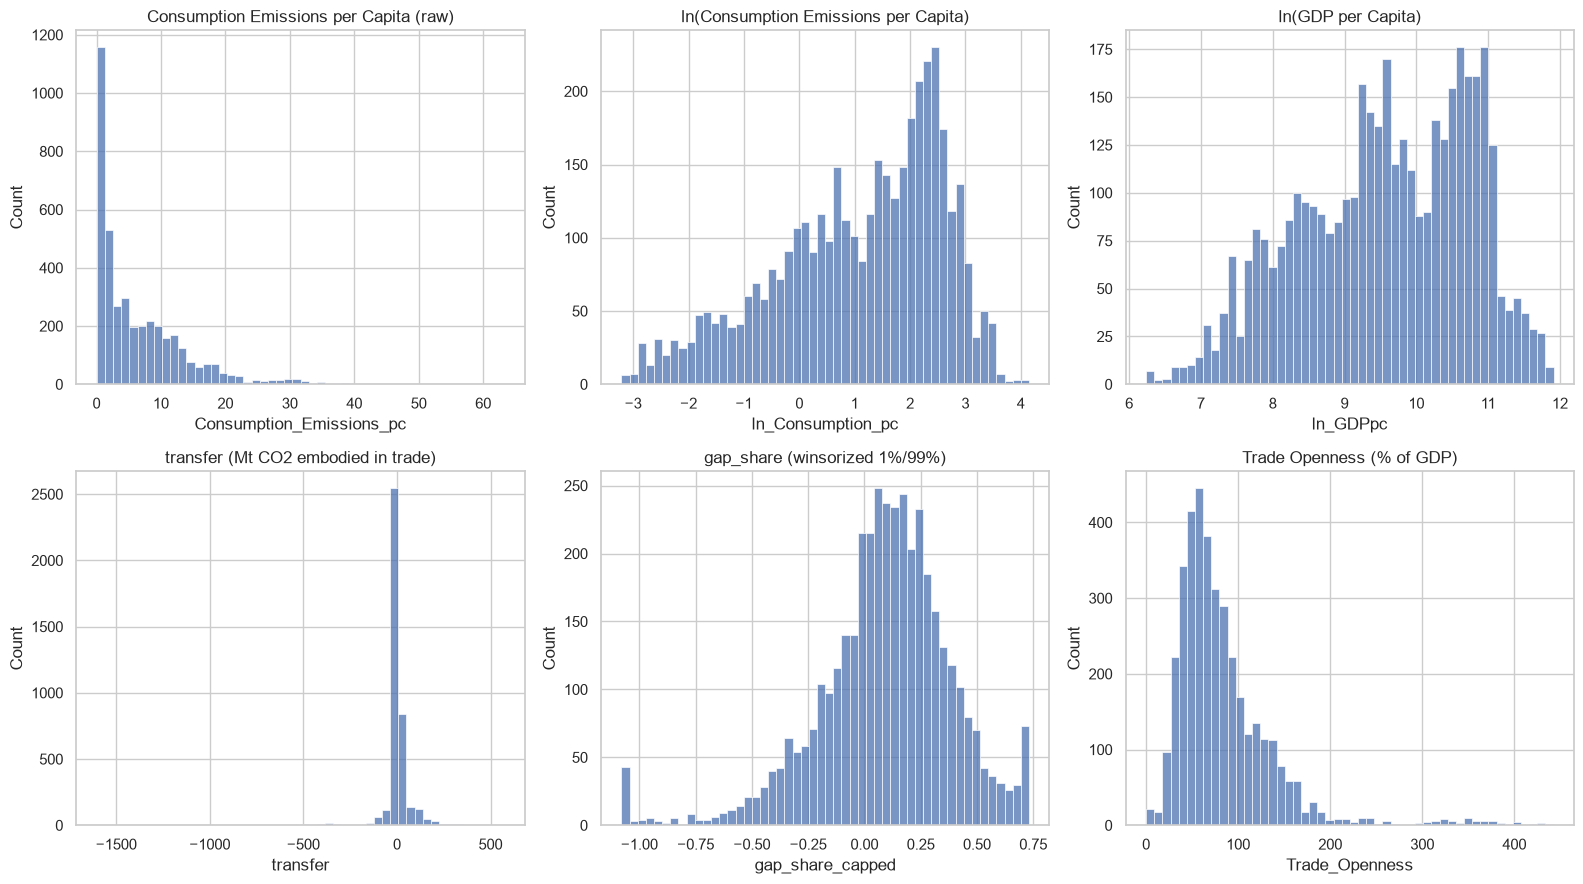

In [103]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df['Consumption_Emissions_pc'], bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Consumption Emissions per Capita (raw)')

sns.histplot(df['ln_Consumption_pc'].dropna(), bins=50, ax=axes[0, 1])
axes[0, 1].set_title('ln(Consumption Emissions per Capita)')

sns.histplot(df['ln_GDPpc'].dropna(), bins=50, ax=axes[0, 2])
axes[0, 2].set_title('ln(GDP per Capita)')

sns.histplot(df['transfer'], bins=50, ax=axes[1, 0])
axes[1, 0].set_title('transfer (Mt CO2 embodied in trade)')

sns.histplot(df['gap_share_capped'].dropna(), bins=50, ax=axes[1, 1])
axes[1, 1].set_title('gap_share (winsorized 1%/99%)')

sns.histplot(df['Trade_Openness'].dropna(), bins=50, ax=axes[1, 2])
axes[1, 2].set_title('Trade Openness (% of GDP)')

plt.tight_layout()
plt.show()

### What these six distributions show

**Top-left — consumption emissions per capita (raw).** Severely right-skewed: 1,157 country-years sit in the lowest bin and the tail runs to 63 t CO₂ per capita. A mean is close to meaningless on this shape, and any linear model in levels would be driven by the tail. This panel exists to justify the log transform next to it.

**Top-middle — ln(consumption per capita).** The log does its job: roughly bell-shaped over −3.2 to +4.2 with a mild left tail. This is the form used in every EKC fit.

**Top-right — ln(GDP per capita). The most consequential panel of the six.** The distribution is clearly **bimodal** — one hump around 9.2–9.7 (≈ $10–16k) and a larger one around 10.5–11 (≈ $36–60k), with a trough near 10.0–10.2. This is the familiar "twin peaks" of the world income distribution, and it has a direct consequence for Section 5: a polynomial fitted across a bimodal *x* can produce curvature that reflects the **gap between two clusters** rather than a smooth relationship within one. The FE turning points in Section 5.4 (ln ≈ 10.6, $39–42k) sit at the foot of the upper hump, which is one reason the bootstrap confidence intervals there matter.



**Bottom-left — `transfer`.** Extremely leptokurtic: ~2,500 country-years within a few Mt of zero and a single arm reaching −1,604 Mt. That arm is China (mainland). This is the clearest statement of why `transfer` in absolute Mt is a problematic variable — it is dominated by a handful of large economies (Section 13).

**Bottom-middle — `gap_share` (winsorised).** Approximately symmetric around +0.10: the typical country consumes slightly more embodied carbon than it produces. **The two spikes at the extremes are the winsorisation itself** — 41 observations clipped to each cap (the top bin looks larger because it also collects the values just below the cap). They are an artefact of the transform, not clusters in the data.

**Bottom-right — trade openness.** Right-skewed, modal around 50–60% of GDP, median 70%, with a thin tail past 300% made of the entrepôt economies — Singapore, Hong Kong SAR, Luxembourg — where re-exports inflate the ratio. They will be high-leverage points in any regression using openness. The small bar at exactly 0 is Venezuela 1991–2011 (the zero-coded gap from Section 1); it disappears once Correction 2 in Section 2 is applied.

## 4. Correlation Structure

Log emissions on both bases, log GDP per capita, `Trade_Openness`, `transfer` and `gap_share_capped` — a collinearity check before any regression, and a first look at where the leakage signal is.

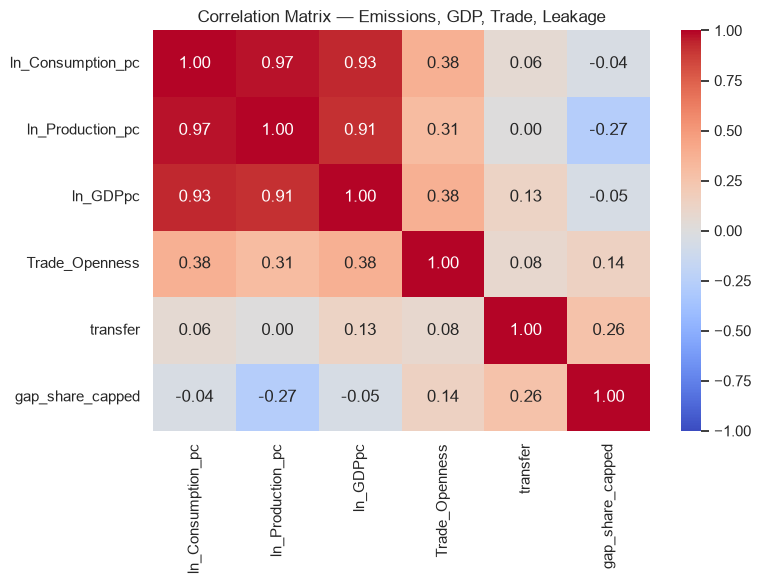

In [104]:
corr_cols = ['ln_Consumption_pc', 'ln_Production_pc', 'ln_GDPpc',
             'Trade_Openness', 'transfer', 'gap_share_capped']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Emissions, GDP, Trade, Leakage')
plt.tight_layout()
plt.show()

### Reading the correlation matrix



- `ln_Consumption_pc` ↔ `ln_Production_pc` = **0.97**
- `ln_Consumption_pc` ↔ `ln_GDPpc` = **0.93**
- `ln_Production_pc` ↔ `ln_GDPpc` = **0.91**

At 0.97 the two emissions measures are almost interchangeable *in levels* — the central reason the leakage analysis works with their **difference** (`transfer`, `gap_share`) rather than the two series side by side. Putting both into one regression would be close to including the same regressor twice.

**`transfer` correlates with essentially nothing** — 0.06, 0.00, 0.13, 0.08 across the board. This looks like "no signal", but it is mostly scale: `transfer` is an absolute quantity in Mt, so it tracks country size, and country size is not what the per-capita, log variables measure. It is evidence that `transfer` needs normalising (Section 12), not that leakage is absent.

**`gap_share_capped` carries the actual signal, and it is modest.** Its strongest relationship is **−0.27 with `ln_Production_pc`**: countries that produce less carbon per head consume proportionally more of someone else's. That is the leakage story as a correlation. Its correlation with `Trade_Openness` is only **+0.14** — weakly in the predicted direction — and with `ln_GDPpc` essentially zero (−0.05).


## 5. EKC Regressions — Pooled OLS vs. Two-Way Fixed Effects

The Environmental Kuznets Curve is specified as a cubic in log income:

$$\ln(E_{it}/N_{it}) = \alpha + \beta_1 x_{it} + \beta_2 x_{it}^2 + \beta_3 x_{it}^3 + \varepsilon_{it}, \qquad x_{it} = \ln(\text{GDP pc}_{it}) - \overline{\ln(\text{GDP pc})}$$

fitted separately for consumption-based and production-based emissions per capita. $\beta_2 < 0$ gives concavity; a *turning point* exists where $\beta_1 + 2\beta_2 x + 3\beta_3 x^2 = 0$ with negative second derivative, and it only means something if it falls inside the observed income range ($511 to $149,025 per capita; centred $x \in [-3.33,\ 2.35]$; sample mean $14,257).

Two estimators are compared:

- **5.1–5.2 Pooled OLS** — no country or year effects. Identifies almost entirely from *between-country* variation (rich countries emit more than poor ones). A descriptive benchmark, not a causal curve.
- **5.3 Two-way fixed effects** (`PanelOLS`, country + year effects, SEs clustered by country) — identifies from *within-country* variation over time: when a given country gets richer, what happens to its own emissions? This is the specification the thesis should report.
- **5.4** recovers the turning point from the FE coefficients; **5.5** shows the pooled scatter for both bases side by side.

The design matrix is shared; `sm.add_constant` adds the intercept the pooled model needs (the FE model absorbs it).

In [105]:
X = df[['ln_gdp_centered', 'ln_gdp_centered_sq', 'ln_gdp_centered_cub']]
X = sm.add_constant(X)
Yc = df['ln_Consumption_pc']
Yp = df['ln_Production_pc']

### 5.1 Pooled OLS — consumption-based emissions

`cov_type='HC3'` corrects for heteroskedasticity only. **It does not correct for the fact that each country contributes 34 serially-correlated observations** — see the note after 5.2.

In [106]:
dc = df[['ln_Consumption_pc', 'ln_gdp_centered', 'ln_gdp_centered_sq', 'ln_gdp_centered_cub', 'ISO3']].dropna()
model_pooled_c = sm.OLS(dc['ln_Consumption_pc'], sm.add_constant(dc.iloc[:, 1:4])).fit(
       cov_type='cluster', cov_kwds={'groups': dc['ISO3']})
print(" Pooled OLS(Ordinary Least Squares) (Cubic EKC)")
print(model_pooled_c.summary())
# Interpret: If β₂ < 0, the inverted-U EKC holds
# If β₃ > 0, it's an N-shaped curve (emissions may rise again)

 Pooled OLS(Ordinary Least Squares) (Cubic EKC)
                            OLS Regression Results                            
Dep. Variable:      ln_Consumption_pc   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     401.1
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           2.23e-61
Time:                        20:59:14   Log-Likelihood:                -3205.4
No. Observations:                3995   AIC:                             6419.
Df Residuals:                    3991   BIC:                             6444.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

### 5.2 Pooled OLS — production-based emissions


In [107]:
dp = df[['ln_Production_pc', 'ln_gdp_centered', 'ln_gdp_centered_sq', 'ln_gdp_centered_cub', 'ISO3']].dropna()
model_pooled_p = sm.OLS(dp['ln_Production_pc'], sm.add_constant(dp.iloc[:, 1:4])).fit(
       cov_type='cluster', cov_kwds={'groups': dp['ISO3']})
print(" Pooled OLS(Ordinary Least Squares) (Cubic EKC)")
print(model_pooled_p.summary())
 

 Pooled OLS(Ordinary Least Squares) (Cubic EKC)
                            OLS Regression Results                            
Dep. Variable:       ln_Production_pc   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     348.5
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           3.80e-58
Time:                        20:59:14   Log-Likelihood:                -3660.7
No. Observations:                3998   AIC:                             7329.
Df Residuals:                    3994   BIC:                             7355.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

### Reading the pooled results — and why their standard errors cannot be quoted

| | β₁ (x) | β₂ (x²) | β₃ (x³) | R² | N | Durbin–Watson |
|---|---|---|---|---|---|---|
| Consumption | 1.249 | −0.113 | −0.030 | 0.874 | 3,995 | **0.157** |
| Production | 1.246 | −0.154 | −0.029 | 0.851 | 3,998 | **0.122** |

**What the coefficients say.** At the sample-mean income (centred x = 0) the income elasticity of emissions is β₁ ≈ 1.25 on both bases: a country 1% richer than another emits about 1.25% more per head. β₂ < 0 means that elasticity declines with income, and it declines faster on the production basis (−0.154 vs −0.113). The cubic term is small and negative on both. R² of 0.85–0.87 is what a cross-country regression of emissions on income always gives — income sorts countries by emissions level extremely well — and it must not be compared with the FE R² below.

**The N.** 4,032 rows minus 34 (Venezuela, no GDP) = 3,998 for production; minus a further 3 (Panama's nulled consumption years) = 3,995 for consumption.


3. For the record, the pooled turning points are **$209,872** (consumption) and **$156,927** (production) — both *above* the richest country-year in the data (Qatar 2011, $149,025), so the pooled cubic never turns within the sample. An earlier version of 5.4 reported these as "confirmed maxima"; it has been corrected to use the FE coefficients.

### 5.3 Two-way fixed effects (country + year), SEs clustered by country

`PanelOLS(..., entity_effects=True, time_effects=True)` removes each country's mean (so the between-country comparison that drove the pooled R² is gone) and each year's mean (so common shocks — 2009, 2020 — and the global technology trend are gone). What is left is: *as this country's income moved relative to its own average, how did its emissions move relative to its own average, net of what happened everywhere that year?*

The `MissingValueWarning` is expected — it is Venezuela and the three Panama rows being dropped. The `\n` printed literally in the header line is a cosmetic bug: change `"\\n=== ..."` to `"\n=== ..."` in both cells.

In [108]:
panel_df = df.set_index(['ISO3', 'Year']) 

fe_model_c = PanelOLS(
    panel_df['ln_Consumption_pc'],
    panel_df[['ln_gdp_centered', 'ln_gdp_centered_sq', 'ln_gdp_centered_cub']], 
    entity_effects=True,    # country fixed effects
    time_effects=True,      # year fixed effects
    ).fit(cov_type='clustered', cluster_entity=True)

print("\\n=== Fixed Effects Panel Model ===")
print(fe_model_c.summary)

\n=== Fixed Effects Panel Model ===
                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_Consumption_pc   R-squared:                        0.3128
Estimator:                   PanelOLS   R-squared (Between):              0.2110
No. Observations:                3995   R-squared (Within):               0.4471
Date:                Thu, Sep 24 2026   R-squared (Overall):              0.2198
Time:                        20:59:14   Log-likelihood                   -272.09
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      582.76
Entities:                         118   P-value                           0.0000
Avg Obs:                       33.856   Distribution:                  F(3,3841)
Min Obs:                       21.000                                           
Max Obs:                       34.000   F-statistic (robust):            

c:\Users\indra\Desktop\Thesis\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [109]:
fe_model_p = PanelOLS(
    panel_df['ln_Production_pc'],
    panel_df[['ln_gdp_centered', 'ln_gdp_centered_sq', 'ln_gdp_centered_cub']], 
    entity_effects=True,    # country fixed effects
    time_effects=True,      # year fixed effects
    ).fit(cov_type='clustered', cluster_entity=True)

print("\\n=== Fixed Effects Panel Model ===")
print(fe_model_p.summary)

\n=== Fixed Effects Panel Model ===
                          PanelOLS Estimation Summary                           
Dep. Variable:       ln_Production_pc   R-squared:                        0.4659
Estimator:                   PanelOLS   R-squared (Between):              0.2489
No. Observations:                3998   R-squared (Within):               0.4929
Date:                Thu, Sep 24 2026   R-squared (Overall):              0.2565
Time:                        20:59:14   Log-likelihood                    623.73
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1117.5
Entities:                         118   P-value                           0.0000
Avg Obs:                       33.881   Distribution:                  F(3,3844)
Min Obs:                       21.000                                           
Max Obs:                       34.000   F-statistic (robust):            

c:\Users\indra\Desktop\Thesis\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


### Reading the fixed-effects results

| | β₁ (x) | β₂ (x²) | β₃ (x³) | R² within | N | countries | Poolability F |
|---|---|---|---|---|---|---|---|
| Consumption | 0.609 (0.104) | −0.230 (0.033) | −0.032 (0.014), *p* = 0.024 | 0.447 | 3,995 | 118 | 85.6 (*p* < 0.001) |
| Production | 0.660 (0.120) | −0.268 (0.031) | −0.042 (0.013), *p* = 0.001 | 0.493 | 3,998 | 118 | 192.9 (*p* < 0.001) |

*(clustered SEs in parentheses)*

**The comparison with the pooled model is the actual finding of this section.**

- **β₁ halves** (1.25 → 0.61–0.66). Between countries, emissions scale almost proportionally with income; within a country over time, a 1% rise in income at the sample-mean income raises emissions by only ~0.6%. Most of the pooled slope was rich countries *being* rich, not countries *getting* rich.
- **β₂ roughly doubles** (−0.11/−0.15 → −0.23/−0.27). The curvature is much stronger within countries. Combined with the smaller β₁, the FE curve peaks well inside the income range — Section 5.4.
- **The cubic term is significant here** (*p* = 0.024 and 0.001 with clustered SEs) where it was not in the pooled model. The cubic specification is justified for the FE model and unjustified for the pooled one — one more reason to report only the former.
- **The production curve is steeper *and* more concave than the consumption curve** on both estimators. Territorial emissions respond to income growth more strongly at low income and flatten sooner at high income than consumption emissions do; the difference is carbon that has moved across a border. This is the dual-EKC divergence of Section 5.5, now estimated within countries rather than read off a pooled scatter.

**Implied income elasticity of emissions, d ln E / d ln GDP, at selected incomes:**

| GDP pc | $1,000 | $5,000 | $14,257 (mean) | $40,000 | $100,000 | $149,025 (max) |
|---|---|---|---|---|---|---|
| Pooled, consumption | 1.23 | 1.39 | 1.25 | 0.92 | 0.47 | 0.23 |
| Pooled, production | 1.44 | 1.47 | 1.25 | 0.83 | 0.31 | 0.04 |
| **FE, consumption** | 1.15 | 0.99 | 0.61 | **0.03** | −0.66 | −1.01 |
| **FE, production** | 1.20 | 1.08 | 0.66 | **−0.03** | −0.86 | −1.29 |

The pooled elasticity is still positive at the richest observation — that curve never turns. The FE elasticity crosses zero at roughly $40,000 on both bases and is clearly negative above $100,000.

**Poolability.** The F-tests (85.6 and 192.9 on 150 restrictions) reject the pooled model decisively: the country and year effects are jointly far from zero. The pooled OLS is therefore misspecified for this panel and should appear in the write-up only as a between-country benchmark.

**Do not read R² 0.31/0.47 against the pooled 0.87.** `linearmodels` reports R² on demeaned data; the pooled R² is mostly the cross-sectional level differences that the FE model removes by construction. The like-for-like number is *R² within* (0.447 / 0.493): the cubic in income explains ~45–50% of each country's own variation over time after removing common year shocks.

### 5.4 EKC turning point from the fixed-effects model

Solving $3\beta_3 x^2 + 2\beta_2 x + \beta_1 = 0$ for the FE coefficients and keeping the root where the second derivative $2\beta_2 + 6\beta_3 x$ is negative (a maximum — the other root is a minimum, far below the poorest country). The centred root is converted back to dollars with $\exp(x^* + \overline{\ln \text{GDP pc}})$.

*Corrected:* this block previously used `model_pooled_c` / `model_pooled_p`, which gave $209,872 and $156,927 — both outside the data — and contradicted Section 15 of the same notebook. It now uses `fe_model_c` / `fe_model_p`.

In [110]:
b1_c = fe_model_c.params['ln_gdp_centered']
b2_c = fe_model_c.params['ln_gdp_centered_sq']
b3_c = fe_model_c.params['ln_gdp_centered_cub']

mean_ln_gdp = df['ln_GDPpc'].mean()

# Solve: 3*b3*x² + 2*b2*x + b1 = 0
a = 3 * b3_c
b = 2 * b2_c
c = b1_c

discriminant = b**2 - 4*a*c

if discriminant >= 0:
    x1 = (-b + np.sqrt(discriminant)) / (2 * a)
    x2 = (-b - np.sqrt(discriminant)) / (2 * a)
    
    # Pick the root that is a maximum (second derivative < 0)
    # Second derivative: 2*b2 + 6*b3*x
    for x in [x1, x2]:
        second_deriv = 2*b2_c + 6*b3_c*x
        if second_deriv < 0:
            turning_point_gdp = np.exp(x + mean_ln_gdp)
            turning_point_centered = x
            print(f"Turning point (cubic): ${turning_point_gdp:,.0f}")
            print(f"  Centered value: {turning_point_centered:.4f}")
            print(f"  Second derivative: {second_deriv:.4f} (negative = confirmed maximum)")
            break
else:
    print("No real turning point exists (discriminant < 0)")

Turning point (cubic): $41,895
  Centered value: 1.0779
  Second derivative: -0.6695 (negative = confirmed maximum)


In [111]:
b1_p = fe_model_p.params['ln_gdp_centered']
b2_p = fe_model_p.params['ln_gdp_centered_sq']
b3_p = fe_model_p.params['ln_gdp_centered_cub']

mean_ln_gdp = df['ln_GDPpc'].mean()

# Solve: 3*b3*x² + 2*b2*x + b1 = 0
a = 3 * b3_p
b = 2 * b2_p
c = b1_p

discriminant = b**2 - 4*a*c

if discriminant >= 0:
    x1 = (-b + np.sqrt(discriminant)) / (2 * a)
    x2 = (-b - np.sqrt(discriminant)) / (2 * a)
    
    # Pick the root that is a maximum (second derivative < 0)
    # Second derivative: 2*b2 + 6*b3*x
    for x in [x1, x2]:
        second_deriv = 2*b2_p + 6*b3_p*x
        if second_deriv < 0:
            turning_point_gdp = np.exp(x + mean_ln_gdp)
            turning_point_centered = x
            print(f"Turning point (cubic): ${turning_point_gdp:,.0f}")
            print(f"  Centered value: {turning_point_centered:.4f}")
            print(f"  Second derivative: {second_deriv:.4f} (negative = confirmed maximum)")
            break
else:
    print("No real turning point exists (discriminant < 0)")

Turning point (cubic): $38,667
  Centered value: 0.9977
  Second derivative: -0.7868 (negative = confirmed maximum)


### Result: a turning point inside the data, on both bases

| Basis | Turning point (FE cubic) | Centred x* | 95% CI (country-cluster bootstrap, 400 reps) | Country-years above it | Inside observed range? |
|---|---|---|---|---|---|
| Consumption | **$41,895** | 1.078 | $28,951 – $64,040 | 886 (22%) | **Yes** |
| Production | **$38,667** | 0.998 | $28,833 – $49,854 | 1,015 (25%) | **Yes** |

Observed income runs from $511 to $149,025 (Qatar 2011), so both point estimates *and both entire confidence intervals* lie inside the sample — a fifth to a quarter of all country-years are past the peak. This is the result the pooled model could not deliver: within countries, emissions per capita stop rising with income at roughly **$40,000 PPP**, and the production-based peak comes about **$3,000 earlier** than the consumption-based one — territorial emissions start falling while consumption emissions are still rising.

**How robust is it?** Re-estimating the FE cubic on subsamples:

| Sample | Consumption TP | Production TP |
|---|---|---|
| Full panel | $41,895 | $38,667 |
| Excluding Gulf/oil exporters (QAT, ARE, KWT, SAU, BRN, OMN, BHR, TTO, NOR) | $37,167 | $33,329 |
| Excluding top 1% of country-years by income | $39,685 | $35,997 |
| Excluding China and the United States | $43,263 | $39,758 |
| 2000–2023 only | $51,417 | $44,808 |
| FE **quadratic** instead of cubic | $60,010 | $54,318 |

A $33k–$51k band across every cut, and the quadratic FE form brackets it from above ($54–60k, bootstrap CIs $32k–$132k, still inside the data). The honest statement is "**the within-country peak lies between roughly $40k and $60k per capita, with the production basis consistently below the consumption basis**" — not a single number.

**Reconciling with Section 15.** Section 15 fits a pooled *quadratic* and finds turning points at $1.3 million and $11 million. Both results are correct for what they estimate. The pooled fit answers "at what income do *richer countries* stop emitting more than poorer ones?" — never, within this sample. The FE fit answers "at what income does *a country* stop emitting more as it grows?" — about $40k. The gap between the two answers is the between-country heterogeneity (oil states, entrepôts, coal-heavy middle-income economies) that fixed effects absorb. The write-up should present the FE turning point as the EKC result and Section 15 as the demonstration that a pooled curve is not one.



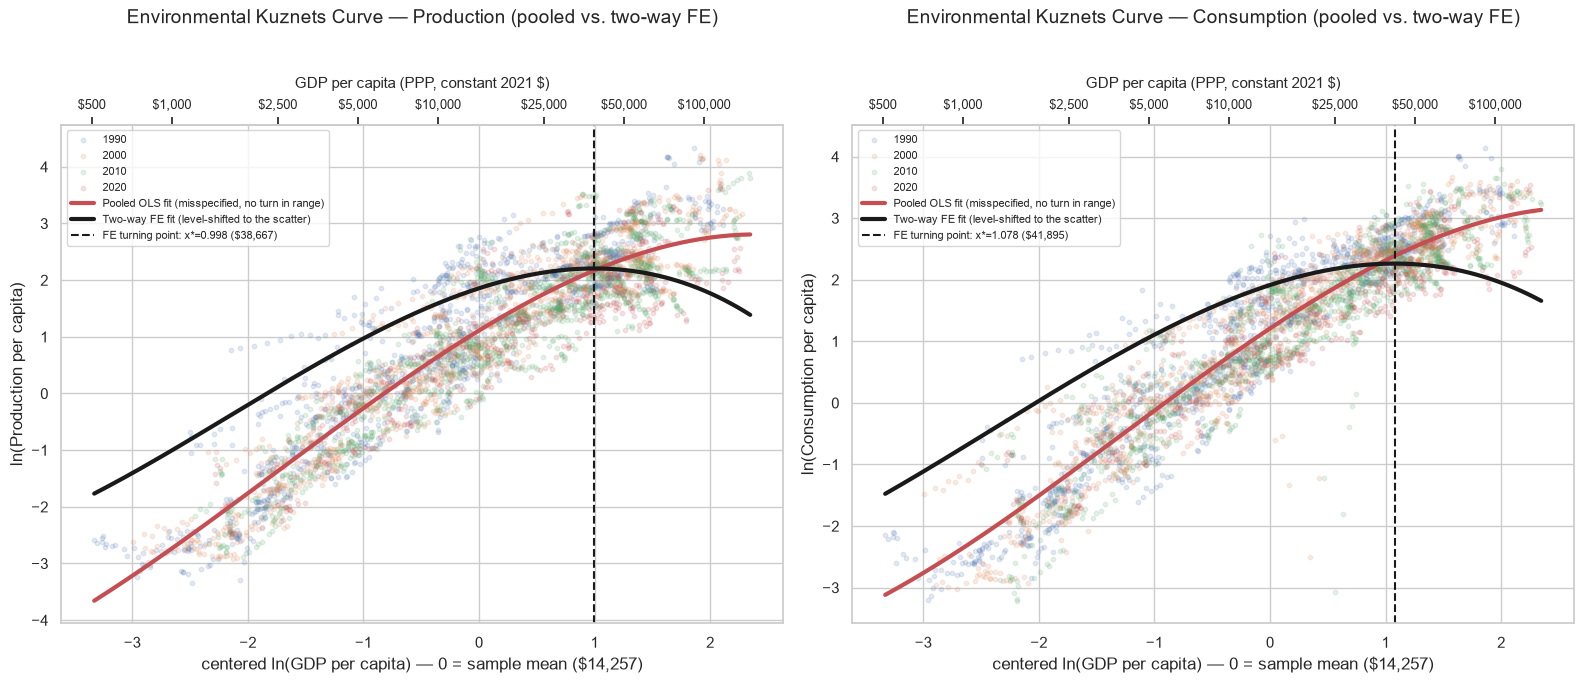

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mean_ln_gdp = df['ln_GDPpc'].mean()
df['Decade'] = (df['Year'] // 10) * 10


def fe_turning_point(model):
    """Centred ln(GDP pc) at the peak of the FE cubic — the root where f'' < 0."""
    b1 = model.params['ln_gdp_centered']
    b2 = model.params['ln_gdp_centered_sq']
    b3 = model.params['ln_gdp_centered_cub']
    disc = (2 * b2) ** 2 - 4 * (3 * b3) * b1
    roots = [(-2 * b2 + s * np.sqrt(disc)) / (6 * b3) for s in (1, -1)]
    return next(x for x in roots if 2 * b2 + 6 * b3 * x < 0)


def fe_curve(model, x, ycol):
    """FE cubic over x. Country and year effects absorb the level, so the polynomial
    carries no intercept of its own — shift it so its mean matches the scatter's."""
    fitted = (model.params['ln_gdp_centered'] * x
              + model.params['ln_gdp_centered_sq'] * x ** 2
              + model.params['ln_gdp_centered_cub'] * x ** 3)
    scatter_mean = df.loc[df['ln_gdp_centered'].notna(), ycol].mean()
    return fitted - fitted.mean() + scatter_mean


# Dollar equivalents for the centred axis: x = ln($) - mean_ln_gdp, so x=0 is the sample
# mean ($14,257), x=1 is e times that ($38,754), x=2 is e**2 times it ($105,346).
DOLLAR_TICKS = [500, 1_000, 2_500, 5_000, 10_000, 25_000, 50_000, 100_000]


def add_dollar_axis(ax):
    """Top axis reading the same data in PPP dollars, so the centred units are legible."""
    secax = ax.secondary_xaxis('top')
    secax.set_xticks([np.log(d) - mean_ln_gdp for d in DOLLAR_TICKS])
    secax.set_xticklabels([f'${d:,.0f}' for d in DOLLAR_TICKS], fontsize=9)
    secax.set_xlabel('GDP per capita (PPP, constant 2021 $)', fontsize=11, labelpad=8)


gdp_range = np.linspace(df['ln_gdp_centered'].min(), df['ln_gdp_centered'].max(), 200)
poly_grid = sm.add_constant(pd.DataFrame({
    'ln_gdp_centered': gdp_range,
    'ln_gdp_centered_sq': gdp_range ** 2,
    'ln_gdp_centered_cub': gdp_range ** 3
}))

# (a) Scatter with fitted curves for Production-based EKC
ax = axes[0]
for decade, group in df.groupby('Decade'):
    ax.scatter(group['ln_gdp_centered'], group['ln_Production_pc'],
               alpha=0.15, s=10, label=str(decade))

ax.plot(gdp_range, model_pooled_p.predict(poly_grid), 'r-', linewidth=3,
        label='Pooled OLS fit (misspecified, no turn in range)')
ax.plot(gdp_range, fe_curve(fe_model_p, gdp_range, 'ln_Production_pc'), 'k-', linewidth=3,
        label='Two-way FE fit (level-shifted to the scatter)')
x_star_p = fe_turning_point(fe_model_p)
ax.axvline(x_star_p, color='k', linestyle='--', linewidth=1.5,
           label=f'FE turning point: x*={x_star_p:.3f} (${np.exp(x_star_p + mean_ln_gdp):,.0f})')
ax.set_xlabel(f'centered ln(GDP per capita) — 0 = sample mean (${np.exp(mean_ln_gdp):,.0f})', fontsize=12)
ax.set_ylabel('ln(Production per capita)', fontsize=12)
ax.set_title('Environmental Kuznets Curve — Production (pooled vs. two-way FE)', fontsize=14, pad=38)
add_dollar_axis(ax)
ax.legend(fontsize=8)

# (b) Scatter with fitted curves for Consumption-based EKC
ax = axes[1]
for decade, group in df.groupby('Decade'):
    ax.scatter(group['ln_gdp_centered'], group['ln_Consumption_pc'],
               alpha=0.15, s=10, label=str(decade))

ax.plot(gdp_range, model_pooled_c.predict(poly_grid), 'r-', linewidth=3,
        label='Pooled OLS fit (misspecified, no turn in range)')
ax.plot(gdp_range, fe_curve(fe_model_c, gdp_range, 'ln_Consumption_pc'), 'k-', linewidth=3,
        label='Two-way FE fit (level-shifted to the scatter)')
x_star_c = fe_turning_point(fe_model_c)
ax.axvline(x_star_c, color='k', linestyle='--', linewidth=1.5,
           label=f'FE turning point: x*={x_star_c:.3f} (${np.exp(x_star_c + mean_ln_gdp):,.0f})')
ax.set_xlabel(f'centered ln(GDP per capita) — 0 = sample mean (${np.exp(mean_ln_gdp):,.0f})', fontsize=12)
ax.set_ylabel('ln(Consumption per capita)', fontsize=12)
ax.set_title('Environmental Kuznets Curve — Consumption (pooled vs. two-way FE)', fontsize=14, pad=38)
add_dollar_axis(ax)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 5.5 Dual EKC — production vs. consumption basis, pooled scatter

The core reason this dataset is more informative than a single-basis EKC: the curve can be drawn twice, once per accounting basis, on identical axes. If the two diverge — the production curve bending earlier or more — that is direct evidence that trade is reshaping the curve, i.e. that part of any "production-based" EKC is carbon leakage rather than decarbonisation. The red lines are pooled quadratics (`sns.regplot(order=2)`); the within-country version of the same comparison is the FE estimate in 5.3.

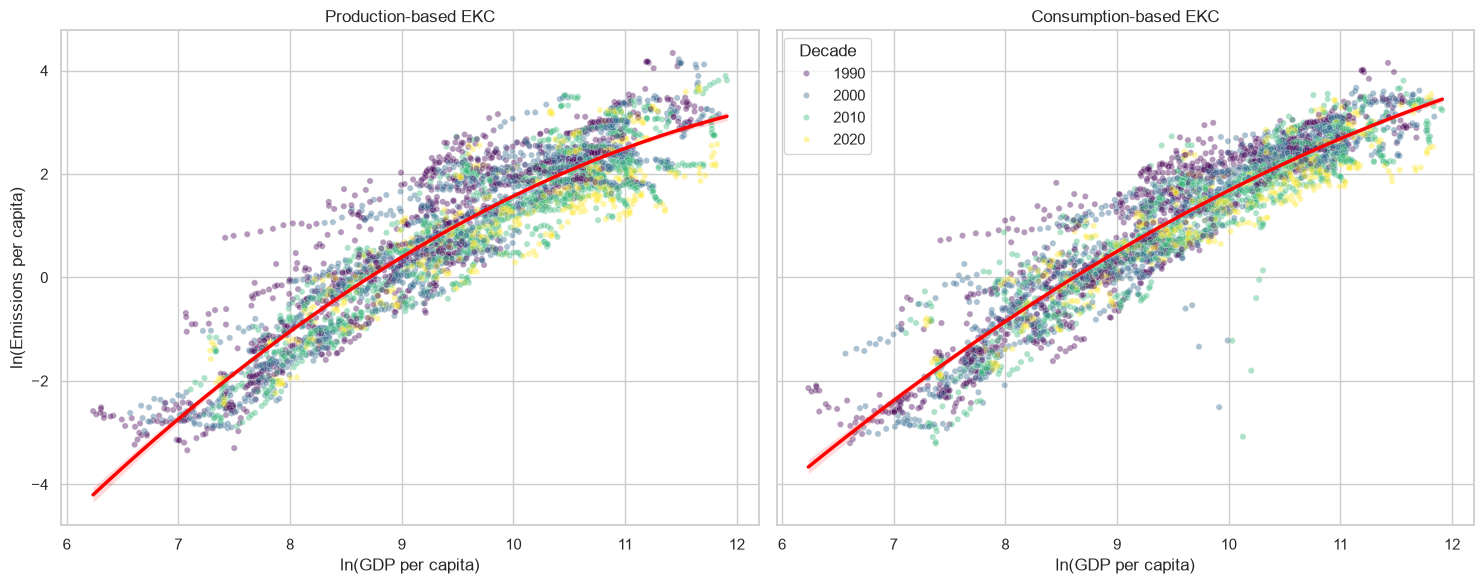

In [113]:
df['Decade'] = (df['Year'] // 10) * 10

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

for ax, y_col, title in [
    (axes[0], 'ln_Production_pc', 'Production-based EKC'),
    (axes[1], 'ln_Consumption_pc', 'Consumption-based EKC'),
]:
    sns.scatterplot(data=df, x='ln_GDPpc', y=y_col, hue='Decade',
                     palette='viridis', alpha=0.4, s=20, ax=ax, legend=(ax is axes[1]))
    sns.regplot(data=df, x='ln_GDPpc', y=y_col, order=2, scatter=False,
                color='red', ax=ax, line_kws={'linewidth': 2.5})
    ax.set_title(title)
    ax.set_xlabel('ln(GDP per capita)')
    ax.set_ylabel('ln(Emissions per capita)')

plt.tight_layout()
plt.show()

### The dual EKC — the central chart of the notebook

Both panels share axes so they can be compared directly. Each point is a country-year, coloured by decade; the red line is a pooled quadratic fit.

**Production-based (left): pronounced concavity.** The fit rises steeply through low and middle incomes, then bends clearly and is close to flat by ln(GDP pc) ≈ 11–12. The 2010s–2020s points (green, yellow) at high income sit visibly *below* the 1990s points (purple) at the same income.

**Consumption-based (right): visibly straighter.** The same countries, the same incomes, but the curve bends far less and is **still rising at the top of the income range**. The decade layering is much weaker.

**The divergence between the two panels is the finding.** Rich countries' *territorial* emissions flatten while their *consumption* emissions keep climbing — the gap between the panels is carbon emitted elsewhere and consumed domestically. That is the leakage hypothesis rendered as a picture, and the argument for why a production-only EKC overstates decoupling. Section 5.3 puts numbers on it: β₂ is −0.268 vs −0.230 within countries, and the production peak comes ~$3,000 before the consumption peak.

**Two caveats that must survive into the write-up:**

1. **Neither *pooled* curve turns down.** Both are monotonically increasing and merely concave over the observed range — Section 15 shows their turning points are at $1.3M and $11M per capita, an order of magnitude beyond the richest observation. The turn *does* exist once country and year effects are included (Section 5.4, ~$40k with CIs inside the data). So: "the pooled curves flatten; the within-country curves peak" — and be explicit about which is being shown.
2. **This is a pooled scatter, not a panel estimate.** No country or year fixed effects, so it blends cross-sectional and time variation and is descriptive only. The decade colouring shows the confound directly: 1990s points sit *above* 2020s points at comparable incomes in the left panel, so some of the apparent curvature is a **downward shift over time** — technology, fuel mix — rather than an income effect. The year effects in 5.3 remove exactly that shift.

## 6. Carbon Leakage Signals

**`transfer` vs. income** — the pollution-haven signature is a negative relationship: rich countries importing embodied carbon, middle-income manufacturing economies exporting it. The extremes are already known: China (mainland) is the largest net exporter (transfer as low as −1,604 Mt in 2008), the United States the largest net importer (+574 Mt in 2006).

**`gap_share` vs. `Trade_Openness`** — tests whether more trade-exposed economies show a bigger gap between what they produce and what they consume.

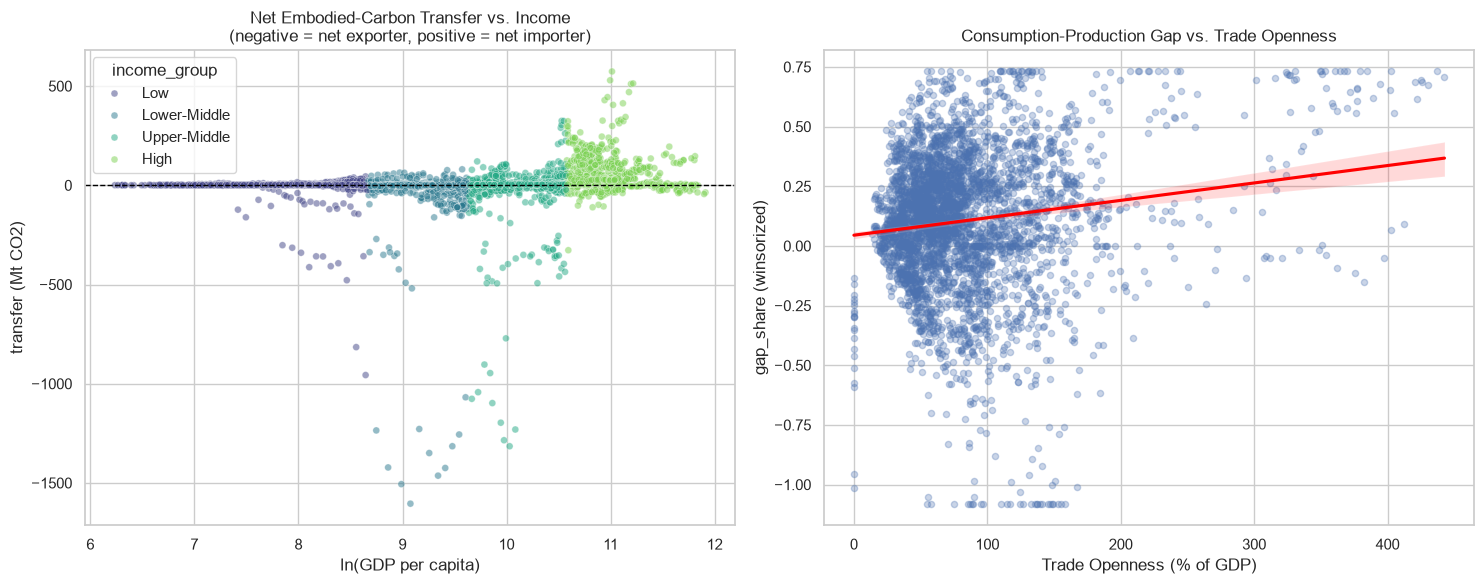

Correlation, transfer vs ln_GDPpc: 0.13
Correlation, gap_share_capped vs Trade_Openness: 0.142


In [114]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='ln_GDPpc', y='transfer', hue='income_group',
                 palette='viridis', alpha=0.5, s=25, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Net Embodied-Carbon Transfer vs. Income\n(negative = net exporter, positive = net importer)')
axes[0].set_xlabel('ln(GDP per capita)')
axes[0].set_ylabel('transfer (Mt CO2)')

sns.regplot(data=df, x='Trade_Openness', y='gap_share_capped', scatter_kws={'alpha': 0.3, 's': 20},
            line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Consumption-Production Gap vs. Trade Openness')
axes[1].set_xlabel('Trade Openness (% of GDP)')
axes[1].set_ylabel('gap_share (winsorized)')

plt.tight_layout()
plt.show()

print("Correlation, transfer vs ln_GDPpc:", df[['transfer', 'ln_GDPpc']].corr().iloc[0, 1].round(3))
print("Correlation, gap_share_capped vs Trade_Openness:", df[['gap_share_capped', 'Trade_Openness']].corr().iloc[0, 1].round(3))

### Two leakage signals, one strong and one weak

**Left — `transfer` vs. income.** The structure is real: the extreme negative values (net exporters) sit at middle incomes around ln(GDP pc) 9–10, while the positive values (net importers) concentrate in the high-income cluster above 10.5. That is the pollution-haven pattern.

**But this panel is dominated by country size, not by leakage intensity.** `transfer` is in absolute Mt, so the visible outliers are simply the largest economies: China (mainland) averages −863 Mt (minimum −1,604), the Russian Federation −412, India −168. Most of the 4,000 points are compressed into an indistinguishable band at zero. Ranking by **per-capita** transfer instead gives a completely different list — Qatar (−16.1 t/person), Trinidad and Tobago (−11.3), Bahrain (−8.7) — small fossil-fuel exporters, none of which are visible here. The correlation of +0.13 between `transfer` and `ln_GDPpc` should therefore not be read as "income barely matters"; it is the scale problem. **Improvement:** redraw this panel with `transfer_pc` on the y-axis — Section 12 has the ranking; the scatter is a one-word change.

**Right — `gap_share` vs. trade openness.** The fitted slope is positive, matching the prediction, but **weak**: r = 0.14, and the confidence band widens sharply beyond 200% openness where data is thin. The cloud is close to circular over the 0–150% range where most observations sit. Section 14 shows this correlation is *entirely* cross-sectional — it vanishes within countries.

Two visual artefacts not to over-read: the **horizontal bands** at the top and bottom are the winsorisation caps from Section 2, and the **vertical stripe at openness = 0** is Venezuela 1991–2011, where openness is recorded as zero instead of missing. After Correction 2 in Section 2 the stripe disappears and the correlation should be recomputed — the 21 rows all lie at x = 0 with widely varying y, so they pull the slope toward zero.

## 7. Time Trends

Average production vs. consumption emissions per capita over 1990–2023 — does the gap widen after China's 2001 WTO accession / the Kyoto Protocol's 2005 entry into force? A widening gap is the leakage story playing out at the aggregate level. (Unweighted country means; Section 16 tests what that choice does.)

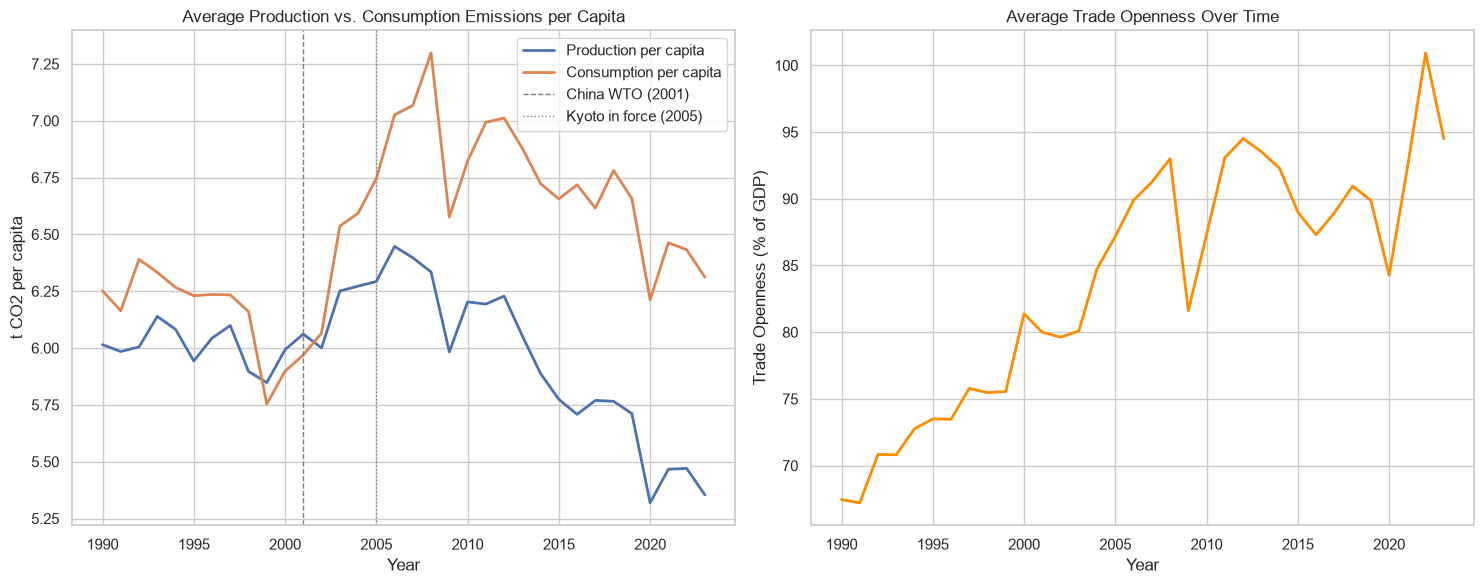

In [115]:
yearly = df.groupby('Year')[['Production_Emissions_pc', 'Consumption_Emissions_pc', 'Trade_Openness']].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(yearly.index, yearly['Production_Emissions_pc'], label='Production per capita', linewidth=2)
axes[0].plot(yearly.index, yearly['Consumption_Emissions_pc'], label='Consumption per capita', linewidth=2)
axes[0].axvline(2001, color='gray', linestyle='--', linewidth=1, label='China WTO (2001)')
axes[0].axvline(2005, color='gray', linestyle=':', linewidth=1, label='Kyoto in force (2005)')
axes[0].set_title('Average Production vs. Consumption Emissions per Capita')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('t CO2 per capita')
axes[0].legend()

axes[1].plot(yearly.index, yearly['Trade_Openness'], color='darkorange', linewidth=2)
axes[1].set_title('Average Trade Openness Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Trade Openness (% of GDP)')

plt.tight_layout()
plt.show()

### Time trends — the aggregate leakage story, with an important confound

**Left panel.** Production and consumption emissions per capita (unweighted country means) track each other from 1990 to about 2001 — consumption slightly above, then slightly below — and then **separate sharply**. Consumption climbs to a peak of **7.3 t per capita in 2008** while production peaks at **6.45 in 2006**, and the gap never closes: after 2012 production falls steadily to **5.35 by 2023** while consumption ends at **6.3**. The 2009 notch is the financial crisis; the 2020 drop is COVID.

The divergence opens right around China's 2001 WTO accession and widens through Kyoto's 2005 entry into force.

**The confound that has to be addressed before this chart can be used as evidence.** These are **unweighted means over a changing set of countries**. Sample composition is not constant — specifically, **Norway enters the panel in 2003**, inside the window where the gap opens. Norway is rich and high-emitting, so its entry mechanically lifts the average at the moment the divergence appears. One country in ~118 cannot explain a gap of this size, but the chart cannot distinguish composition from behaviour. Section 16 recomputes it on the balanced 117-country panel.

An **unweighted country mean** treats Luxembourg and China as equal observations, so this is "the average country", not "the world" — a population-weighted version answers a different and arguably more relevant question. And because production and consumption are two accountings of the *same* global emissions, a persistent gap in the *average* reflects the composition of this 119-country sample rather than a global imbalance.

**Right panel.** Average trade openness rises from about 67% of GDP in 1990 to roughly 95% by 2023 (peaking above 100% in 2022), with the 2009 collapse and 2020 dip visible. The openness mechanism has a strong secular trend — a warning for any regression of a trending outcome on it, since both co-move with time regardless of any causal link. Year fixed effects are the standard remedy, and Section 14 shows that once country means are removed the openness–gap correlation is zero.


## 8. Cross-Country Ranking: Net Exporters vs. Importers of Embodied Carbon

Rank countries by their average `transfer` over the full period, then relate net-exporter/importer status to income group. The naive pollution-haven prediction is "exporters skew toward lower income"; the crosstab below shows that is the wrong way to state it, and why.

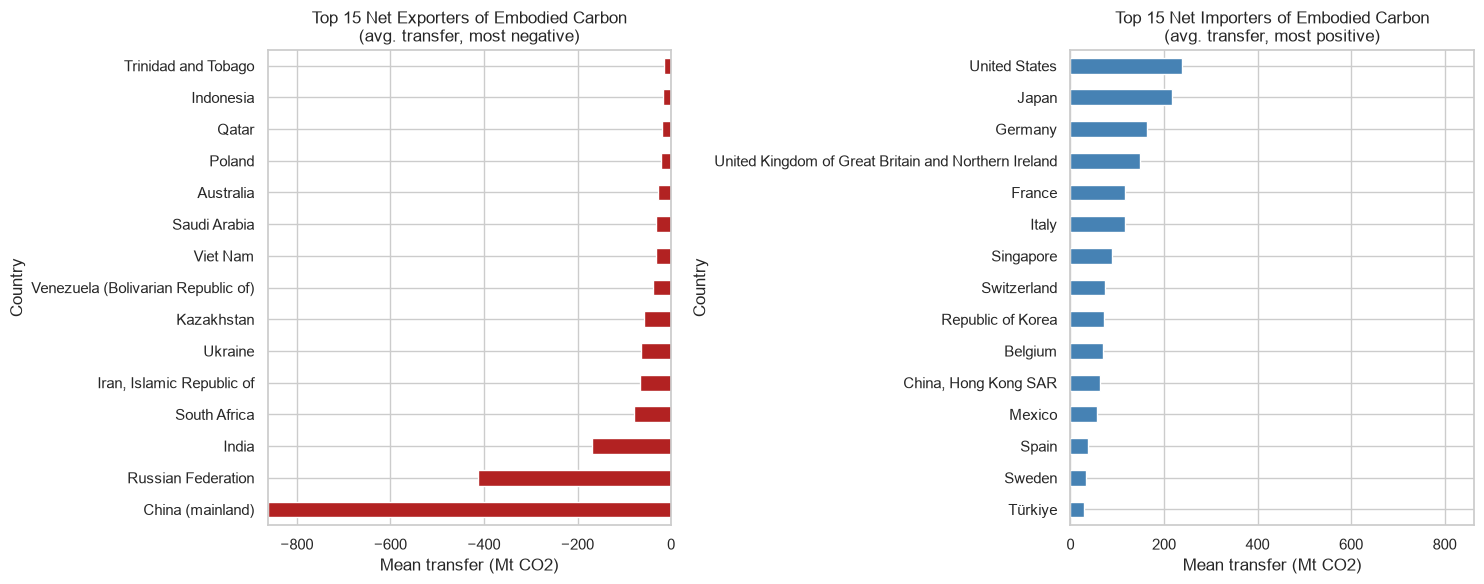

Common scale: 0 to 863 Mt CO2 on both panels


In [ ]:
country_transfer = df.groupby('Country')['transfer'].mean().sort_values()

top_exporters = country_transfer.head(15)   # most negative = biggest net exporters
top_importers = country_transfer.tail(15)   # most positive = biggest net importers

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_exporters.plot(kind='barh', ax=axes[0], color='firebrick')
axes[0].set_title('Top 15 Net Exporters of Embodied Carbon\n(avg. transfer, most negative)')
axes[0].set_xlabel('Mean transfer (Mt CO2)')

top_importers.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Net Importers of Embodied Carbon\n(avg. transfer, most positive)')
axes[1].set_xlabel('Mean transfer (Mt CO2)')


span = max(abs(top_exporters.min()), top_importers.max())
axes[0].set_xlim(-span, 0)
axes[1].set_xlim(0, span)

plt.tight_layout()
plt.show()

print(f'Common scale: 0 to {span:,.0f} Mt CO2 on both panels')

### Who exports and who imports embodied carbon

**Left — net exporters.** China (mainland) dominates at roughly −863 Mt on average, more than twice the Russian Federation (−412) and five times India (−168). The remainder is coherent: heavy-manufacturing and fossil-fuel economies (South Africa, Iran, Ukraine, Kazakhstan, Venezuela, Viet Nam, Saudi Arabia, Indonesia, Qatar, Trinidad and Tobago). Australia and Poland are the two OECD members — both large coal producers, which fits.

**Right — net importers.** The wealthy consumer economies: United States (+239), Japan (+217), Germany (+163), United Kingdom (+149), France (+118), Italy (+117), then Singapore, Switzerland, Republic of Korea, Belgium, Hong Kong SAR, Spain and Sweden. Mexico and Türkiye are the only non-high-income entries.

**Both panels share a common scale** (0 to 863 Mt). Without it the left axis would run to −900 and the right to +250, making China's bar look comparable to the USA's while being 3.6× larger. With identical units the asymmetry is visible: the largest exporters move far more carbon than the largest importers, because export-embodied carbon is concentrated in a few manufacturing giants while import-embodied carbon is spread across many rich countries.

**The normalisation caveat still applies:** this ranks by absolute Mt, so it is close to a ranking of large economies. Section 12 repeats it per capita and gets an almost entirely different list.

In [ ]:
latest_year = df['Year'].max()
latest = df[df['Year'] == latest_year][['Country', 'income_group']]

status = country_transfer.rename('mean_transfer').reset_index()
status['status'] = np.where(status['mean_transfer'] < 0, 'Net exporter', 'Net importer')
status = status.merge(latest, on='Country', how='left')

pd.crosstab(status['income_group'], status['status'])

status,Net exporter,Net importer
income_group,,
Low,1,18
Lower-Middle,10,14
Upper-Middle,12,20
High,11,32


### Net status by income group — the result that contradicts the naive prediction

The naive prediction is "exporters skew toward lower income". **The table shows the opposite**, and this deserves to be addressed rather than passed over:

| Income group | Net exporter | Net importer |
|---|---|---|
| Low | 1 | 18 |
| Lower-Middle | 10 | 14 |
| Upper-Middle | 12 | 20 |
| High | 11 | 32 |

Low-income countries are net **importers** 18 times out of 19. Net exporters are most common in the middle of the distribution, not the bottom.

This is not evidence against the pollution-haven hypothesis so much as a consequence of how `transfer` is defined. Being a net *exporter* of embodied carbon requires a large export manufacturing base, which low-income countries do not have — they import most manufactured goods and so import the carbon embodied in them. The leakage story runs through **middle-income industrial exporters** (China, India, Viet Nam), which is exactly where the exporter counts concentrate. The prediction should be restated in those terms.

**Two technical caveats on the table itself.** The counts sum to 118, not 119 — Venezuela has no `GDP_per_capita` and therefore no `income_group`, so it silently drops out. And `income_group` is taken from the **latest year only** (2023) while `mean_transfer` is averaged over all 34 years, so a country that changed bracket over the period is classified by where it ended up. Both are defensible; neither was previously stated. Section 18 suggests a country-level income classification that removes the second issue.

## 9. Export Cleaned Base Data

In [118]:
base_cols = ['Country', 'ISO3', 'Year', 'Consumption_Emissions', 'Production_Emissions',
             'transfer','transfer_pc','Consumption_Emissions_pc', 'Production_Emissions_pc','gap_share_pro','gap_share_con', 'GDP_per_capita', 'Trade_Openness', 'Population']

# The treatment coding travels WITH the base data. These are not analysis-specific
# derivations like the winsorization threshold - they are the treatment definition of the
# thesis, built and asserted in data_integ.ipynb. Making a downstream notebook rebuild them
# is how two notebooks end up disagreeing about who is treated.
treat_cols = [c for c in ['annex_b', 'first_treat', 'post', 'rel_year', 'country_id',
                          'first_treat_2008', 'post_2008', 'rel_year_2008'] if c in df.columns]

clean_path = DATA_DIR / 'data_final_clean.csv'
df[base_cols + treat_cols].to_csv(clean_path, index=False)

print(f'Wrote {df.shape[0]} rows x {len(base_cols + treat_cols)} columns to {clean_path}')
print(f'  base columns:      {base_cols}')
print(f'  treatment columns: {treat_cols}')
print('\nRemaining known gaps (unchanged, left for downstream analysis to decide how to handle):')
print(f"  - GDP_per_capita missing: {df['GDP_per_capita'].isna().sum()} rows (Venezuela, all years)")
print(f"  - Trade_Openness missing: {df['Trade_Openness'].isna().sum()} rows (Jamaica/Nigeria/Trinidad & Tobago fully, others partially)")
print(f"  - Consumption_Emissions missing: {df['Consumption_Emissions'].isna().sum()} rows (Panama's 3 impossible values, nulled in Section 2)")
print('  - Norway Consumption_Emissions: only 2003-2023 (genuine source gap, see data_integ.ipynb)')

Wrote 4032 rows x 22 columns to C:\Users\indra\Desktop\Thesis\Final project for thesis\Data\data_final_clean.csv
  base columns:      ['Country', 'ISO3', 'Year', 'Consumption_Emissions', 'Production_Emissions', 'transfer', 'transfer_pc', 'Consumption_Emissions_pc', 'Production_Emissions_pc', 'gap_share_pro', 'gap_share_con', 'GDP_per_capita', 'Trade_Openness', 'Population']
  treatment columns: ['annex_b', 'first_treat', 'post', 'rel_year', 'country_id', 'first_treat_2008', 'post_2008', 'rel_year_2008']

Remaining known gaps (unchanged, left for downstream analysis to decide how to handle):
  - GDP_per_capita missing: 34 rows (Venezuela, all years)
  - Trade_Openness missing: 227 rows (Jamaica/Nigeria/Trinidad & Tobago fully, others partially)
  - Consumption_Emissions missing: 3 rows (Panama's 3 impossible values, nulled in Section 2)
  - Norway Consumption_Emissions: only 2003-2023 (genuine source gap, see data_integ.ipynb)


## 10. Descriptive Statistics and Treatment/Control Balance

Everything above pools the whole panel. But the thesis is a difference-in-differences on **Annex B vs. non-Annex B**, and up to this point `annex_b` has not been used once. This section provides the two tables a panel study is expected to open with: full-sample descriptives, and a **pre-treatment balance check** between the group that took on Kyoto commitments and the group that did not.

Balance is measured with the **normalised difference** (Imbens–Rubin), $(\bar{x}_T - \bar{x}_C)/\sqrt{(s^2_T + s^2_C)/2}$, rather than a *t*-statistic. A *t*-test answers "is the difference distinguishable from zero given the sample size", which in a 4,000-row panel is almost always yes; the normalised difference answers "how far apart are these groups in units of their own spread", which is what actually threatens a DiD. The conventional warning threshold is **0.25**.

In [119]:
ANALYSIS_VARS = ['Consumption_Emissions_pc', 'Production_Emissions_pc', 'transfer_pc',
                 'gap_share_capped', 'GDP_per_capita', 'Trade_Openness']

print('=== Full-sample descriptive statistics ===')
desc = df[ANALYSIS_VARS].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
desc.columns = ['n', 'mean', 'sd', 'min', 'median', 'max']
print(desc.round(2).to_string())


def balance_table(data, varlist, group_col='annex_b'):
    """Group means/SDs plus the Imbens-Rubin normalized difference (scale-free)."""
    treated, control = data[data[group_col] == 1], data[data[group_col] == 0]
    rows = []
    for v in varlist:
        a, b = treated[v].dropna(), control[v].dropna()
        nd = (a.mean() - b.mean()) / np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
        rows.append({'variable': v, 'annexB_mean': a.mean(), 'annexB_sd': a.std(),
                     'control_mean': b.mean(), 'control_sd': b.std(),
                     'norm_diff': nd, 'imbalanced': 'YES' if abs(nd) > 0.25 else ''})
    return pd.DataFrame(rows).set_index('variable')


pre = df[df['Year'] < 2005]
print('\n=== Pre-treatment balance, 1990-2004 (before Kyoto entered into force) ===')
print(balance_table(pre, ANALYSIS_VARS).round(3).to_string())
print(f"\nCountries: {pre[pre.annex_b == 1].ISO3.nunique()} Annex B, "
      f"{pre[pre.annex_b == 0].ISO3.nunique()} never-treated")

print('\n=== Pre-period covariate missingness by group (%) ===')
print((pre.groupby('annex_b')[['GDP_per_capita', 'Trade_Openness']]
       .apply(lambda g: g.isna().mean() * 100)).round(1).to_string())

=== Full-sample descriptive statistics ===
                               n      mean        sd     min    median        max
Consumption_Emissions_pc  4029.0      6.50      7.18    0.04      4.06      63.27
Production_Emissions_pc   4032.0      5.97      7.58    0.04      3.58      76.72
transfer_pc               4029.0      0.53      3.84  -39.86      0.16      36.17
gap_share_capped          4029.0      0.09      0.30   -1.08      0.11       0.73
GDP_per_capita            3998.0  25224.37  25265.07  510.82  15277.53  149025.12
Trade_Openness            3805.0     84.03     56.16    0.00     69.85     442.62

=== Pre-treatment balance, 1990-2004 (before Kyoto entered into force) ===
                          annexB_mean  annexB_sd  control_mean  control_sd  norm_diff imbalanced
variable                                                                                        
Consumption_Emissions_pc       10.743      4.451         4.436       7.511      1.022        YES
Production_Emiss

### What the balance table says — and it is not good news for an unconditional DiD

**The two groups are profoundly different before treatment ever begins.** Every substantive variable except trade openness breaches the 0.25 threshold, most by a wide margin:

| Variable | Annex B | Control | Norm. diff. |
|---|---|---|---|
| GDP per capita | $35,715 | $14,914 | **1.04** |
| Consumption emissions pc | 10.74 t | 4.44 t | **1.02** |
| Production emissions pc | 9.58 t | 4.66 t | **0.70** |
| `transfer_pc` | +1.16 t | −0.23 t | **0.45** |
| `gap_share_capped` | 0.092 | 0.021 | **0.26** |
| Trade openness | 78.7% | 74.1% | 0.10 |

Annex B countries were already **2.4× richer** and emitted **2.4× more per capita** before Kyoto — not a surprise, since Annex B *is* essentially the list of countries that were industrialised in 1992. But it means the control group is not a plausible stand-in for what treated countries would have done absent treatment, and a raw treated-vs-control comparison is not identifying a treatment effect.

**This does not sink the design** — DiD does not require balanced *levels*, only parallel *trends*, which is tested in Section 11. It does mean:

1. The parallel-trends evidence has to carry the entire identifying burden, so it must be shown, not asserted.
2. Level differences of this size make functional form matter. An additive effect on `transfer_pc` and a proportional one imply very different things when baseline levels differ by 2.4×.
3. `gap_share` is the better-behaved outcome: it is already normalised, and its imbalance (0.26) is at the threshold rather than four times over it.

**One encouraging result:** trade openness — the main economic confounder for a leakage story — is well balanced (0.10). And pre-period missingness is *lower* in the treated group (4.8% vs 7.8% for openness), so the gaps flagged in Section 1 are not concentrated where they would do the most damage. (The 7.8% control figure will rise slightly once Venezuela's zero-coded openness is nulled.)

## 11. Parallel Trends — the Identifying Assumption

This is the assumption the entire difference-in-differences rests on: absent Kyoto, Annex B and non-Annex B outcomes would have continued to move **in parallel**. It cannot be proven, but it can be falsified, and a study that does not try is not credible.

Two pieces of evidence below:

1. **Visual** — group means by year, with the 2005 entry into force marked. The pre-2005 portion is the part that matters.
2. **Formal** — a differential pre-trend test on 1990–2004 data only:
   $y_{it} = \alpha + \beta_1 \text{AnnexB}_i + \beta_2 t + \beta_3 (\text{AnnexB}_i \times t) + \varepsilon_{it}$
   where $\beta_3$ is the difference in slopes. Under parallel trends $\beta_3 = 0$. Standard errors are **clustered by country** — the same correction the pooled OLS in Section 5.1 is missing — since a country's outcomes are serially correlated and treating 1,771 country-years as independent would understate them badly.

Each test is also run **excluding Norway**, which enters the panel only in 2003 and so contributes just two pre-treatment years (Section 1).

*Corrected:* the cluster-robust OLS below is hand-rolled because an earlier environment lacked `statsmodels`. It is installed now (Section 5 uses it). The function is kept because it is a dozen transparent lines and reproduces `sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': d['ISO3']})` exactly — but that one-liner is the simpler replacement.

In [120]:
def ols_cluster(y, X, clusters):
    """OLS with cluster-robust (CR1) standard errors, clustered on `clusters`."""
    y, X, clusters = np.asarray(y, float), np.asarray(X, float), np.asarray(clusters)
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    XtX_inv = np.linalg.pinv(X.T @ X)

    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(clusters):                 # sum of within-cluster score outer products
        m = clusters == g
        u = X[m].T @ resid[m]
        meat += np.outer(u, u)

    n, k = X.shape
    G = len(np.unique(clusters))
    V = XtX_inv @ meat @ XtX_inv * (G / (G - 1)) * ((n - 1) / (n - k))   # CR1 finite-sample fix
    return beta, np.sqrt(np.diag(V)), G


def pretrend_test(data, outcome, drop_iso=()):
    """Differential pre-2005 trend between Annex B and control. H0: no differential trend."""
    d = data[(data['Year'] < 2005) & data[outcome].notna()]
    if drop_iso:
        d = d[~d['ISO3'].isin(drop_iso)]
    t = d['Year'] - 2004                          # 0 in the last pre-treatment year
    X = np.column_stack([np.ones(len(d)), d['annex_b'], t, d['annex_b'] * t])
    beta, se, G = ols_cluster(d[outcome], X, d['ISO3'])
    tstat = beta[3] / se[3]
    return {'outcome': outcome, 'diff_trend_per_yr': beta[3], 'cluster_se': se[3],
            't': tstat, 'p_value': 2 * (1 - stats.t.cdf(abs(tstat), G - 1)),
            'n': len(d), 'countries': G,
            'parallel_trends': 'OK' if 2 * (1 - stats.t.cdf(abs(tstat), G - 1)) > 0.10 else 'VIOLATED'}


results = []
for outcome in ['gap_share_capped', 'transfer_pc', 'ln_Consumption_pc']:
    results.append(pretrend_test(df, outcome))
    r = pretrend_test(df, outcome, drop_iso=('NOR',))
    r['outcome'] = outcome + ' (ex-Norway)'
    results.append(r)

print('=== Differential pre-trend test, 1990-2004 (SEs clustered by country) ===')
print(pd.DataFrame(results).set_index('outcome').round(4).to_string())

=== Differential pre-trend test, 1990-2004 (SEs clustered by country) ===
                               diff_trend_per_yr  cluster_se       t  p_value     n  countries parallel_trends
outcome                                                                                                       
gap_share_capped                          0.0047      0.0043  1.0874   0.2791  1771        119              OK
gap_share_capped (ex-Norway)              0.0047      0.0043  1.0827   0.2812  1769        118              OK
transfer_pc                               0.0806      0.0509  1.5823   0.1163  1771        119              OK
transfer_pc (ex-Norway)                   0.0807      0.0511  1.5787   0.1171  1769        118              OK
ln_Consumption_pc                        -0.0173      0.0058 -2.9826   0.0035  1771        119        VIOLATED
ln_Consumption_pc (ex-Norway)            -0.0174      0.0058 -2.9966   0.0033  1769        118        VIOLATED


**Now the visual check.** The test above summarises the pre-treatment period in one coefficient per outcome; the plots below show the actual paths, which is where a non-linear divergence would be visible even if the linear test failed to reject.

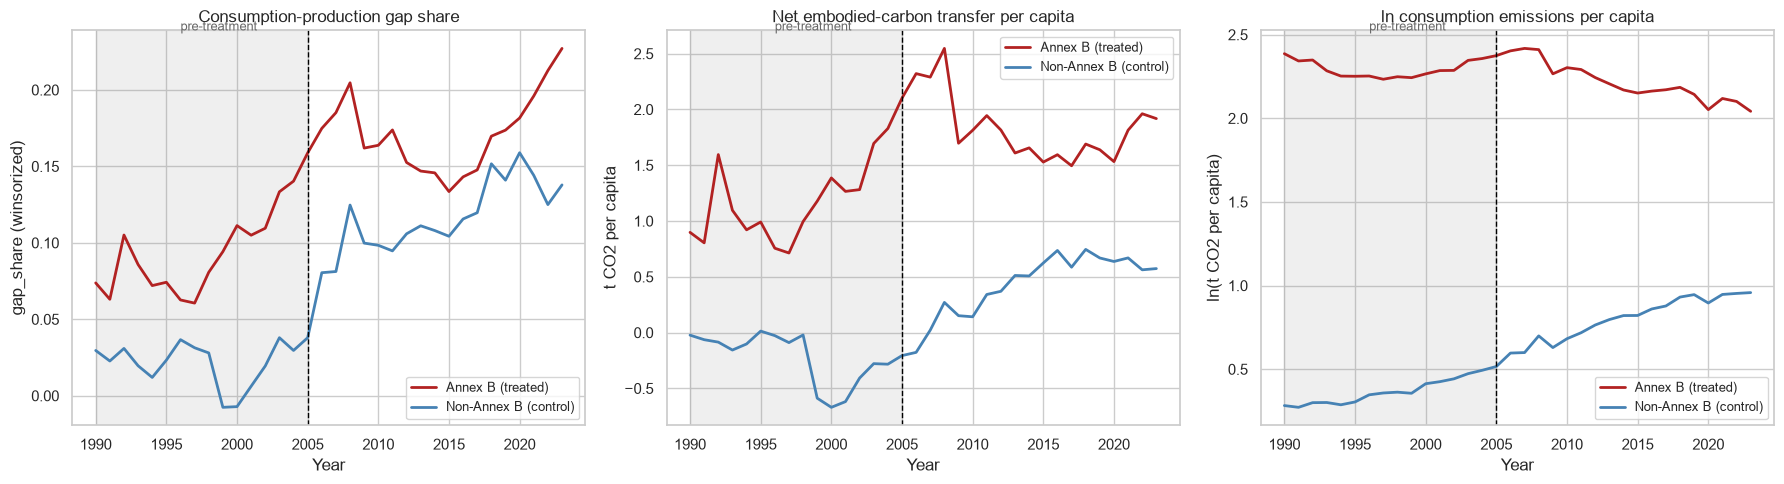

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

panels = [('gap_share_capped', 'gap_share (winsorized)', 'Consumption-production gap share'),
          ('transfer_pc', 't CO2 per capita', 'Net embodied-carbon transfer per capita'),
          ('ln_Consumption_pc', 'ln(t CO2 per capita)', 'ln consumption emissions per capita')]

for ax, (col, ylab, title) in zip(axes, panels):
    means = df[df[col].notna()].groupby(['Year', 'annex_b'])[col].mean().unstack()
    ax.plot(means.index, means[1], label='Annex B (treated)', color='firebrick', linewidth=2)
    ax.plot(means.index, means[0], label='Non-Annex B (control)', color='steelblue', linewidth=2)

    # Shade the pre-treatment window - the only part that tests the assumption
    ax.axvspan(1990, 2005, color='grey', alpha=0.12)
    ax.axvline(2005, color='black', linestyle='--', linewidth=1)
    ax.annotate('pre-treatment', xy=(1996, ax.get_ylim()[1]), fontsize=9, color='dimgrey')
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylab)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Result: the leakage outcomes pass, the levels outcome fails

| Outcome | Differential pre-trend / yr | Cluster SE | p | Verdict |
|---|---|---|---|---|
| `gap_share_capped` | +0.0047 | 0.0043 | 0.28 | **OK** |
| `transfer_pc` | +0.0806 | 0.0509 | 0.12 | **OK** |
| `ln_Consumption_pc` | −0.0173 | 0.0058 | **0.003** | **VIOLATED** |

**The two leakage outcomes survive the test.** Neither `gap_share_capped` nor `transfer_pc` shows a differential pre-2005 slope distinguishable from zero, and in the left and middle panels the two lines climb roughly together through the shaded pre-treatment window. This is the single most important result in the notebook for the credibility of the design, and it is genuinely supportive.

**Emissions in levels fail it decisively.** Annex B consumption per capita was already growing **1.7 percentage points per year slower** than the control group before Kyoto existed (p = 0.003) — visible in the right panel as two lines that diverge well before 2005. Any DiD using `ln_Consumption_pc` as the outcome would attribute a pre-existing divergence to the treaty. **This is a concrete finding, not a technicality: use the gap measures, not emissions levels.**


## 12. Normalised Leakage Measures

Every leakage chart so far uses `transfer` in absolute Mt CO₂, which mostly ranks countries by **size**. Two normalisations make cross-country comparison meaningful:

- **`transfer_pc`** — tonnes CO₂ per person. "How much embodied carbon does the average resident import or export?"
- **`transfer_per_mUSD`** — tonnes CO₂ per $m of PPP GDP. "How carbon-intensive is this economy's net trade position?"

These answer a genuinely different question from the absolute measure, and they give a different answer.

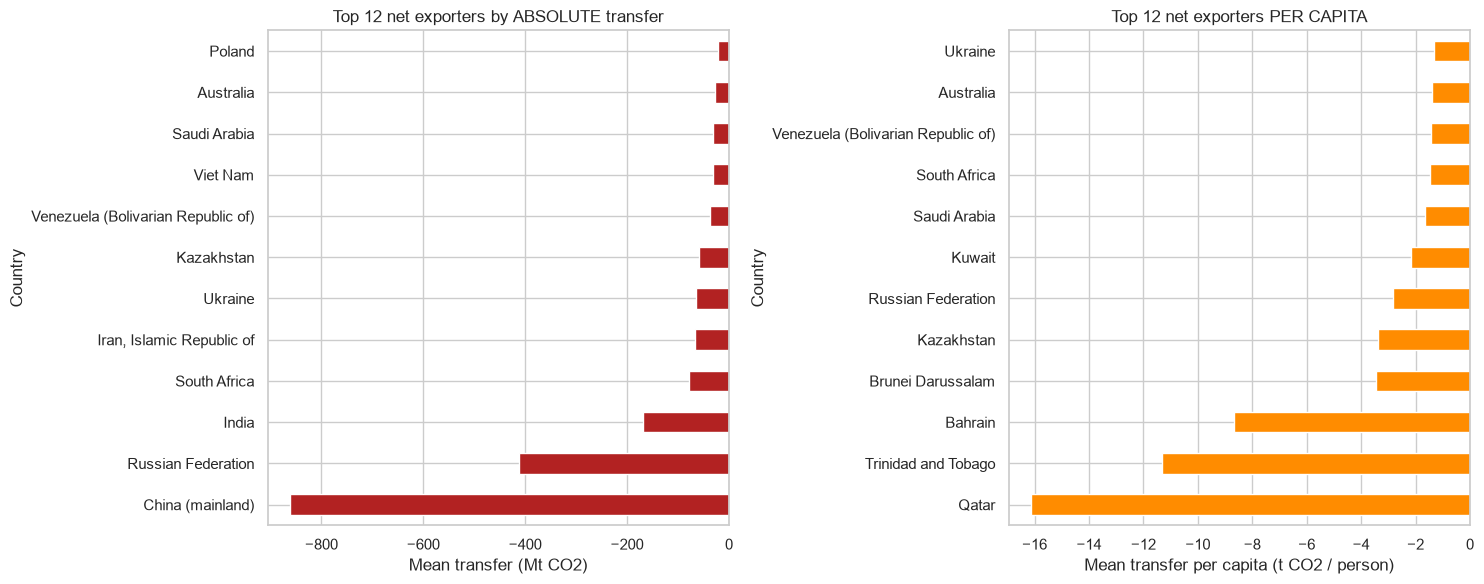

Countries in BOTH top-12 exporter lists: 7 of 12 -> ['Australia', 'Kazakhstan', 'Russian Federation', 'Saudi Arabia', 'South Africa', 'Ukraine', 'Venezuela (Bolivarian Republic of)']
Spearman rank correlation across all 119 countries: 0.863

Same country, two stories:
                     abs_Mt  per_capita_t  per_mUSD_t
Country                                              
China (mainland)    -862.73         -0.64      -79.19
India               -168.29         -0.13      -23.87
Russian Federation  -412.23         -2.81     -107.35
Qatar                -20.19        -16.15     -154.48
Trinidad and Tobago  -15.68        -11.31     -415.32
Bahrain               -9.07         -8.67     -159.68
United States        238.64          0.75       11.86
Luxembourg            -0.03         -0.01       -0.17


In [122]:
rank_abs = df.groupby('Country')['transfer'].mean().sort_values()
rank_pc = df.groupby('Country')['transfer_pc'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

rank_abs.head(12).plot(kind='barh', ax=axes[0], color='firebrick')
axes[0].set_title('Top 12 net exporters by ABSOLUTE transfer')
axes[0].set_xlabel('Mean transfer (Mt CO2)')

rank_pc.head(12).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 12 net exporters PER CAPITA')
axes[1].set_xlabel('Mean transfer per capita (t CO2 / person)')

plt.tight_layout()
plt.show()

overlap = set(rank_abs.head(12).index) & set(rank_pc.head(12).index)
rho = stats.spearmanr(rank_abs, rank_pc.reindex(rank_abs.index)).statistic
print(f'Countries in BOTH top-12 exporter lists: {len(overlap)} of 12 -> {sorted(overlap)}')
print(f'Spearman rank correlation across all 119 countries: {rho:.3f}')
print()
print('Same country, two stories:')
comparison = pd.DataFrame({'abs_Mt': rank_abs, 'per_capita_t': rank_pc,
                           'per_mUSD_t': df.groupby('Country')['transfer_per_mUSD'].mean()})
print(comparison.loc[['China (mainland)', 'India', 'Russian Federation', 'Qatar', 'Trinidad and Tobago',
                      'Bahrain', 'United States', 'Luxembourg']].round(2).to_string())

### The two measures identify different countries



**By absolute transfer** the biggest net exporters are China (mainland) (−863 Mt), the Russian Federation (−412) and India (−168) — the largest manufacturing economies.

**Per capita, the top of the list is entirely different:** Qatar (−16.1 t/person), Trinidad and Tobago (−11.3), Bahrain (−8.7), Brunei Darussalam and Kazakhstan (−3.4 each) lead. Qatar, Trinidad, Bahrain and Brunei are small fossil-fuel and petrochemical exporters whose totals are modest but whose per-person intensity is extreme; Kazakhstan is the one member of the per-capita top five that also ranks highly in absolute terms (7th).

The rank shifts for the headline countries are large: **China moves from 1st to 16th**, India from 3rd to 29th, while **Qatar moves from 13th to 1st**. The Russian Federation is the most consistent of the big exporters — 2nd absolute, 6th per capita.

Per unit of GDP the ordering shifts again: Trinidad and Tobago (−415 t per $m), Bahrain (−160), Qatar (−154), Russia (−107), China (−79), India (−24). The United States is +0.75 t per person and +12 t per $m; Luxembourg is ≈ 0 on every measure.

Seven of the twelve countries appear on both top-12 lists and the Spearman correlation across all 119 is 0.863, so the two measures are not unrelated — but the agreement comes from the middle of the distribution, and it is the top of the ranking that carries the argument.

**Which one is right depends on the question, and the thesis should say which it is asking:**

- *"Which countries move the most carbon through trade?"* → absolute. The right frame for global accounting; China genuinely dominates it.
- *"Which economies are most leakage-intensive?"* → per capita or per unit GDP. The right frame for a **pollution-haven** argument, which is a claim about the character of an economy, not its size.

Section 8's conclusion that low-income countries are overwhelmingly net *importers* is partly an artefact of the absolute measure: their populations are large and their trade volumes small, so they sit near zero and are classified by sign alone. `transfer_pc` separates "barely trades embodied carbon" from "genuinely a carbon haven"; absolute Mt cannot.

## 13. Outlier Sensitivity

China alone drives the `transfer` distribution, the left panel of Section 6 and the whole of Section 8. A descriptive result that survives only with one country in the sample is not a result. This section recomputes the headline statistics with China removed, and with the five largest movers removed.

**Correction — silent no-op.** `df['Country'] != 'China'` matches **no rows** in the current data (the name is `China (mainland)`), so the "excluding China" row would silently equal the full sample. The output shown below is from an earlier run when the name was `China`; on the current data the same numbers are obtained with `df['ISO3'] != 'CHN'`. Filter on `ISO3` here and everywhere else.

Five largest |mean transfer|: ['China (mainland)', 'Russian Federation', 'United States', 'Japan', 'India']

                        n_country_years  mean_transfer_Mt  sd_transfer_Mt  mean_transfer_pc  corr(gap, trade_open)  corr(gap, ln_prod_pc)
sample                                                                                                                                   
all countries                      4032            -0.005         114.182             0.530                  0.142                 -0.269
excluding China                    3998             7.337          69.098             0.540                  0.138                 -0.267
excluding top-5 movers             3862             8.693          37.815             0.563                  0.128                 -0.264


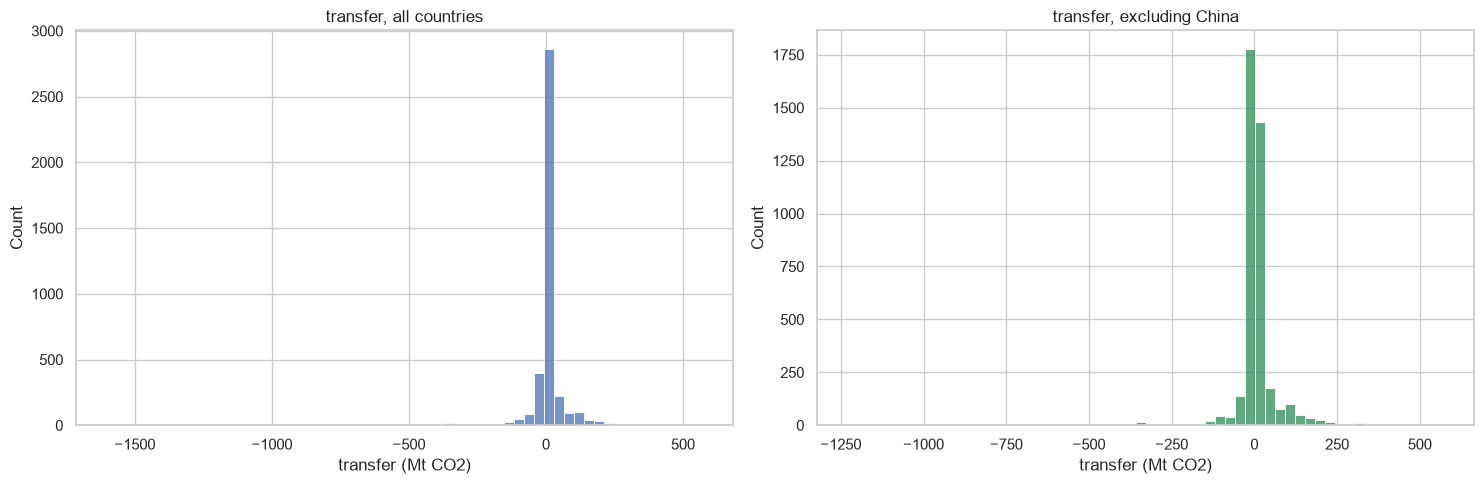

In [38]:
movers = df.groupby('Country')['transfer'].mean().abs().sort_values(ascending=False).head(5)
print('Five largest |mean transfer|:', list(movers.index))

rows = []
for label, d in [('all countries', df),
                 ('excluding China', df[df['ISO3'] != 'CHN']),
                 ('excluding top-5 movers', df[~df['Country'].isin(movers.index)])]:
    rows.append({
        'sample': label,
        'n_country_years': len(d),
        'mean_transfer_Mt': d['transfer'].mean(),
        'sd_transfer_Mt': d['transfer'].std(),
        'mean_transfer_pc': d['transfer_pc'].mean(),
        'corr(gap, trade_open)': d[['gap_share_capped', 'Trade_Openness']].corr().iloc[0, 1],
        'corr(gap, ln_prod_pc)': d[['gap_share_capped', 'ln_Production_pc']].corr().iloc[0, 1],
    })

print()
print(pd.DataFrame(rows).set_index('sample').round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['transfer'], bins=60, ax=axes[0])
axes[0].set_title('transfer, all countries')
axes[0].set_xlabel('transfer (Mt CO2)')
sns.histplot(df.loc[df['ISO3'] != 'CHN', 'transfer'], bins=60, ax=axes[1], color='seagreen')
axes[1].set_title('transfer, excluding China')
axes[1].set_xlabel('transfer (Mt CO2)')
plt.tight_layout()
plt.show()

### The correlations are robust; the moments are not

| Sample | mean transfer | SD transfer | corr(gap, openness) | corr(gap, ln prod pc) |
|---|---|---|---|---|
| All (4,032) | −0.005 | 114.2 | 0.142 | −0.269 |
| Excluding China (3,998) | +7.34 | 69.1 | 0.138 | −0.267 |
| Excluding top-5 movers (3,862) | +8.69 | 37.8 | 0.128 | −0.264 |

*(Re-verified on the current data with the `ISO3` filter; unchanged by the renaming.)*

**The relationships hold.** Both key correlations barely move when China or the five largest movers (China, Russia, United States, Japan, India) are dropped — `gap_share` ↔ `ln_Production_pc` stays at roughly −0.27 throughout. The leakage signal in Section 4 is a property of the whole panel, not of one country.

**The distribution statistics do not hold, and should not be quoted.** Removing China alone cuts the standard deviation of `transfer` by 40% (114 → 69) and shifts the mean from approximately zero to +7.3 Mt. The mean of `transfer` being ≈ 0 across all countries is not a finding about world trade — it is China's large negative value offsetting the sum of many small positive ones.

The right-hand histogram shows the distribution is well-behaved once China is removed: still right-skewed, but no longer a single spike with one arm reaching −1,604 Mt. **Any descriptive statistic on absolute `transfer` should be reported both ways**, or reported on `transfer_pc`, where no single country dominates.

## 14. Within-Country Correlation Structure

Section 4's correlations are **pooled**: they mix variation *between* countries (rich countries differ from poor ones) with variation *within* a country *over time* (a country gets richer). The panel estimators this thesis uses — the fixed effects in Section 5.3, the DiD — discard the between-country variation entirely and identify only from the within dimension.

So the pooled matrix describes variation the models never use. Subtracting each country's own mean from every variable leaves exactly the variation that does the work.

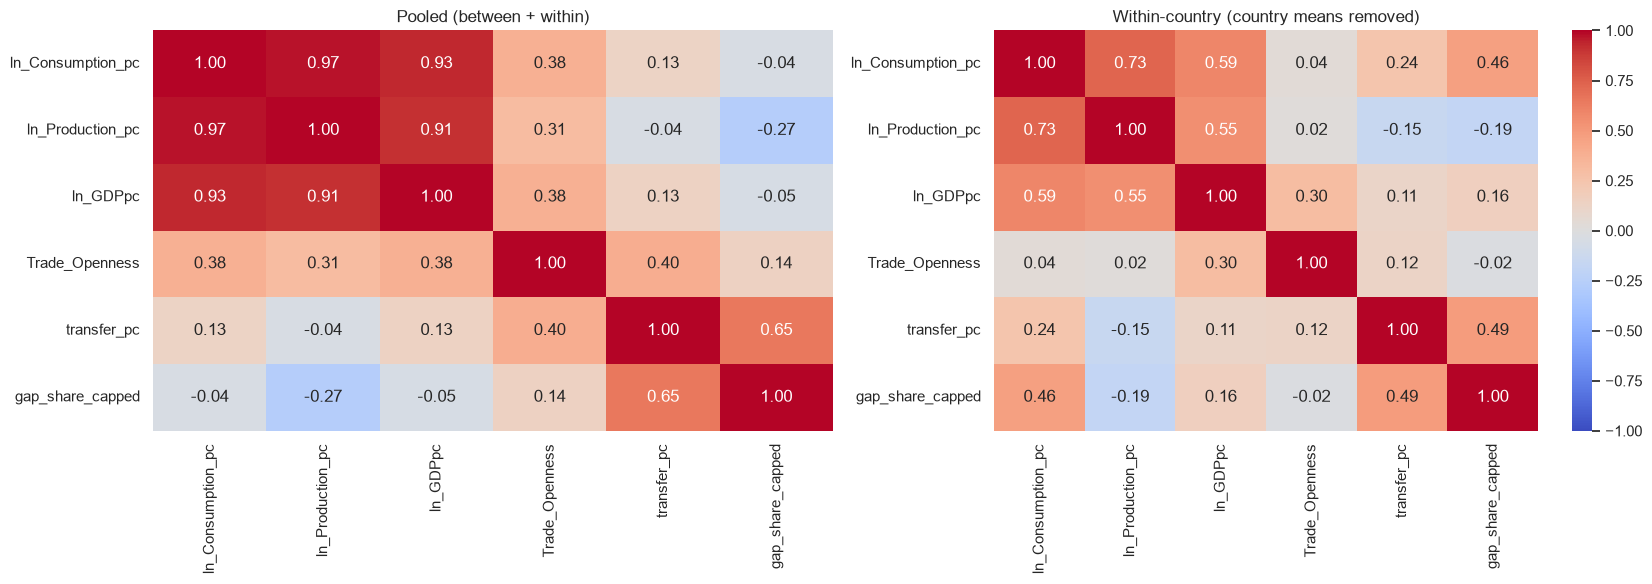

Largest changes between the two matrices:
ln_Consumption_pc  gap_share_capped    0.50
ln_Production_pc   ln_GDPpc           -0.37
ln_Consumption_pc  ln_GDPpc           -0.34
                   Trade_Openness     -0.34
ln_Production_pc   Trade_Openness     -0.29
Trade_Openness     transfer_pc        -0.27


In [124]:
CORR_VARS = ['ln_Consumption_pc', 'ln_Production_pc', 'ln_GDPpc',
             'Trade_Openness', 'transfer_pc', 'gap_share_capped']

pooled = df[CORR_VARS].corr()
within = (df[CORR_VARS] - df.groupby('ISO3')[CORR_VARS].transform('mean')).corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for ax, mat, title in [(axes[0], pooled, 'Pooled (between + within)'),
                       (axes[1], within, 'Within-country (country means removed)')]:
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, ax=ax, cbar=(ax is axes[1]))
    ax.set_title(title)
plt.tight_layout()
plt.show()

print('Largest changes between the two matrices:')
diff = (within - pooled).where(np.triu(np.ones(pooled.shape), 1).astype(bool)).stack()
print(diff.reindex(diff.abs().sort_values(ascending=False).index).head(6).round(2).to_string())

### The pooled correlations are substantially misleading

Three changes matter, and each one alters what the thesis can claim:

**1. The trade-openness result disappears.** `gap_share` ↔ `Trade_Openness` falls from **+0.14 pooled to −0.02 within**. The positive association in Section 6 is **entirely cross-sectional**: more open economies have larger consumption–production gaps than less open ones, but a country becoming more open over time shows *no* tendency to widen its own gap. Since a fixed-effects or DiD specification uses only the within variation, that regressor will contribute nothing — and the pollution-haven mechanism, as usually stated, is a claim about *change*. This is arguably the most consequential single number in the notebook.

**2. `gap_share` ↔ `ln_Consumption_pc` flips sign**, −0.04 pooled to **+0.46 within**. Across countries, footprint size says nothing about outsourcing; within a country, years of higher consumption per capita are strongly years of a larger imported share. That is a real and plausible mechanism — demand booms are met by imports — and it is invisible in the pooled matrix.

**3. The collinearity problem is much smaller than it looked.** `ln_Consumption_pc` ↔ `ln_Production_pc` drops from 0.97 to 0.73, and both against `ln_GDPpc` from ~0.92 to 0.55–0.59. The near-perfect correlations in Section 4 were mostly the fixed fact that rich countries emit more. Once country means are removed there is far more independent variation to identify from than the pooled matrix implied — which is also why the FE model in Section 5.3 recovers a curve the pooled model cannot.

**Implication:** report the within-country matrix, not the pooled one, as the diagnostic for the panel models — or report both and explain the difference, which is more informative still.

## 15. EKC Turning Points — the Pooled Quadratic, for Contrast

Section 5.5 shows two concave *pooled* curves. Concavity is not enough: an EKC requires the relationship to **turn downward** inside the observed income range. A quadratic will always report a turning point somewhere — the question is whether it is $40,000 per capita or $10 million.

For $y = \beta_0 + \beta_1 x + \beta_2 x^2$ with $x = \ln(\text{GDP pc})$, the turning point is $x^* = -\beta_1 / (2\beta_2)$. Confidence intervals come from a **cluster bootstrap that resamples countries**, not rows — resampling rows would treat 34 observations of one country as 34 independent draws and produce a badly overconfident interval.

This section deliberately estimates the *pooled* curve. Section 5.4 does the same exercise with country and year fixed effects and gets a very different answer; reading the two together is the point.

In [125]:
def ekc_turning_point(data, ycol, n_boot=600, seed=0):
    """Quadratic EKC fit; turning point with a country-cluster bootstrap CI."""
    d = data[[ycol, 'ln_GDPpc', 'ISO3']].dropna()
    y, x, iso = d[ycol].to_numpy(float), d['ln_GDPpc'].to_numpy(float), d['ISO3'].to_numpy()

    def fit(yy, xx):
        X = np.column_stack([np.ones(len(xx)), xx, xx ** 2])
        b = np.linalg.lstsq(X, yy, rcond=None)[0]
        return b, (-b[1] / (2 * b[2]) if b[2] != 0 else np.nan)

    beta, point = fit(y, x)

    rng = np.random.default_rng(seed)
    countries = np.unique(iso)
    idx_by_country = {c: np.flatnonzero(iso == c) for c in countries}
    boot = []
    for _ in range(n_boot):
        pick = rng.choice(countries, len(countries), replace=True)
        idx = np.concatenate([idx_by_country[c] for c in pick])
        boot.append(fit(y[idx], x[idx])[1])
    boot = np.array(boot, float)
    boot = boot[np.isfinite(boot)]
    ci = np.percentile(boot, [2.5, 97.5])

    return {'beta2': beta[2], 'tp_ln_gdp': point, 'tp_usd': np.exp(point),
            'ci_lo_usd': np.exp(ci[0]), 'ci_hi_usd': np.exp(ci[1]),
            'observed_max_usd': np.exp(x.max()),
            'turns_within_data': bool(x.min() < point < x.max())}


ekc = pd.DataFrame([{'basis': 'Production', **ekc_turning_point(df, 'ln_Production_pc')},
                    {'basis': 'Consumption', **ekc_turning_point(df, 'ln_Consumption_pc')}]
                   ).set_index('basis')
print('=== EKC quadratic turning points (cluster-bootstrapped, 600 reps) ===')
print(ekc.round(3).to_string())
print()
for basis, r in ekc.iterrows():
    print(f"{basis:12}: turning point at ${r['tp_usd']:,.0f} per capita "
          f"(95% CI ${r['ci_lo_usd']:,.0f} - ${r['ci_hi_usd']:,.0f}); "
          f"richest observed country-year is ${r['observed_max_usd']:,.0f}")
    print(f"{'':12}  -> turns within observed data: {r['turns_within_data']}")

=== EKC quadratic turning points (cluster-bootstrapped, 600 reps) ===
             beta2  tp_ln_gdp        tp_usd   ci_lo_usd     ci_hi_usd  observed_max_usd  turns_within_data
basis                                                                                                     
Production  -0.128     14.106  1.337096e+06  241582.991  1.637996e+08        149025.116              False
Consumption -0.088     16.228  1.116644e+07  694473.875  4.133032e+14        149025.116              False

Production  : turning point at $1,337,096 per capita (95% CI $241,583 - $163,799,626); richest observed country-year is $149,025
              -> turns within observed data: False
Consumption : turning point at $11,166,441 per capita (95% CI $694,474 - $413,303,233,550,872); richest observed country-year is $149,025
              -> turns within observed data: False


**And the same result shown graphically.** The dotted vertical line marks the richest country-year in the sample (Qatar 2011); the fitted turning points lie far to its right, off the edge of the data entirely.

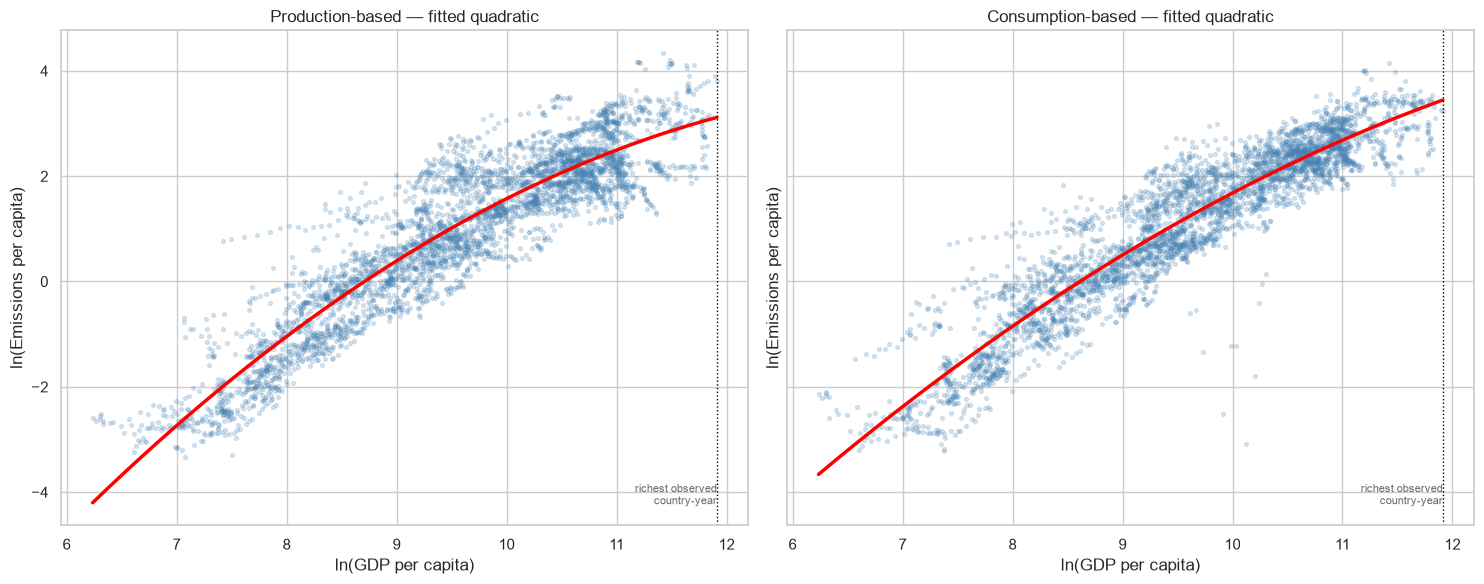

Both fitted turning points lie far to the RIGHT of the dotted line, i.e. outside the data.


In [126]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
xs = np.linspace(df['ln_GDPpc'].min(), df['ln_GDPpc'].max(), 200)

for ax, ycol, title in [(axes[0], 'ln_Production_pc', 'Production-based'),
                        (axes[1], 'ln_Consumption_pc', 'Consumption-based')]:
    d = df[[ycol, 'ln_GDPpc']].dropna()
    ax.scatter(d['ln_GDPpc'], d[ycol], s=8, alpha=0.2, color='steelblue')
    X = np.column_stack([np.ones(len(d)), d['ln_GDPpc'], d['ln_GDPpc'] ** 2])
    b = np.linalg.lstsq(X, d[ycol], rcond=None)[0]
    ax.plot(xs, b[0] + b[1] * xs + b[2] * xs ** 2, color='red', linewidth=2.5)
    ax.set_title(f'{title} — fitted quadratic')
    ax.set_xlabel('ln(GDP per capita)')
    ax.set_ylabel('ln(Emissions per capita)')
    ax.axvline(df['ln_GDPpc'].max(), color='black', linestyle=':', linewidth=1)
    ax.annotate('richest observed\ncountry-year', xy=(df['ln_GDPpc'].max(), ax.get_ylim()[0] + 0.4),
                ha='right', fontsize=8, color='dimgrey')

plt.tight_layout()
plt.show()

print('Both fitted turning points lie far to the RIGHT of the dotted line, i.e. outside the data.')

### The pooled curve has no turning point in this data

| Basis | Turning point (pooled quadratic) | 95% CI | Richest observed | Turns within data? |
|---|---|---|---|---|
| Production | **$1,337,000** /capita | $242k – $164m | $149,025 | **No** |
| Consumption | **$11,166,000** /capita | $694k – $4.1×10¹⁴ | $149,025 | **No** |

The production-based curve turns at roughly **$1.34 million per capita** — about **nine times** the richest country-year in the panel (**Qatar 2011, $149,025**; Luxembourg's maximum is $138,683 in 2007). The consumption-based curve turns at $11 million, and its upper confidence bound is not a meaningful number. In both cases the entire confidence interval sits outside the observed income range.

*Corrected:* the richest country-year was previously attributed to Luxembourg.

**The pooled quadratic is fitting concavity, not a peak.** Across countries, emissions rise with income at a decreasing rate over the whole observed range and never turn down. The correct description of the *between-country* relationship is "the elasticity of emissions with respect to income falls as countries get richer" — not "there is an EKC".

**But the within-country curve does peak — Section 5.4.** With country and year fixed effects the turning point is $41,895 (consumption) and $38,667 (production), with bootstrap CIs of $29k–$64k and $29k–$50k, entirely inside the data. The two sections are not in conflict: the pooled fit is dominated by the fact that oil states, entrepôts and coal-heavy middle-income economies sit far off any common curve, and fixed effects absorb exactly that heterogeneity. The write-up should say: **no EKC is visible across countries; an EKC peaking around $40k is visible within them; and on both estimators the production curve is more concave than the consumption curve.**

**On that last point:** β₂ is −0.128 on the production basis versus −0.088 on the consumption basis in the pooled quadratic (about 45% more concave), and −0.268 versus −0.230 in the FE cubic. Territorial emissions decouple from income faster than consumption emissions do on every specification, and the difference is the carbon being emitted somewhere else.

**Two limits on the pooled estimates.** They blend cross-country and over-time variation (Section 14 shows how much difference that makes), and the bimodal income distribution from Section 3 means the curvature is partly fitted across the gap between two income clusters. Both push the same way: treat these turning points as evidence that a *pooled* turning point does not exist, not as estimates of where one is.

## 16. Sample Composition — Balanced Panel and Population Weighting

Section 7's widening production–consumption gap is the notebook's most suggestive chart, so it deserves the most scrutiny. It is an **unweighted mean over a changing set of countries**, and both of those choices can manufacture a trend that is not there. Two checks:

1. **Balanced panel** — restrict to countries observed in all 34 years, removing composition change (in particular Norway, which enters in 2003, inside the window where the gap opens).
2. **Population weighting** — treat the panel as a set of *people* rather than a set of *countries*, so Luxembourg no longer counts as much as China.

Balanced panel: 117 of 119 countries (dropped ['NAM', 'NOR'])

Consumption minus production, t CO2 per capita:
      All countries, unweighted  Balanced panel, unweighted  All countries, population-weighted  Balanced panel, population-weighted
Year                                                                                                                                
1990                      0.237                       0.237                               0.020                                0.020
2000                     -0.095                      -0.095                               0.003                                0.003
2004                      0.320                       0.311                              -0.000                               -0.001
2010                      0.619                       0.577                              -0.013                               -0.016
2023                      0.958                       0.956                               0

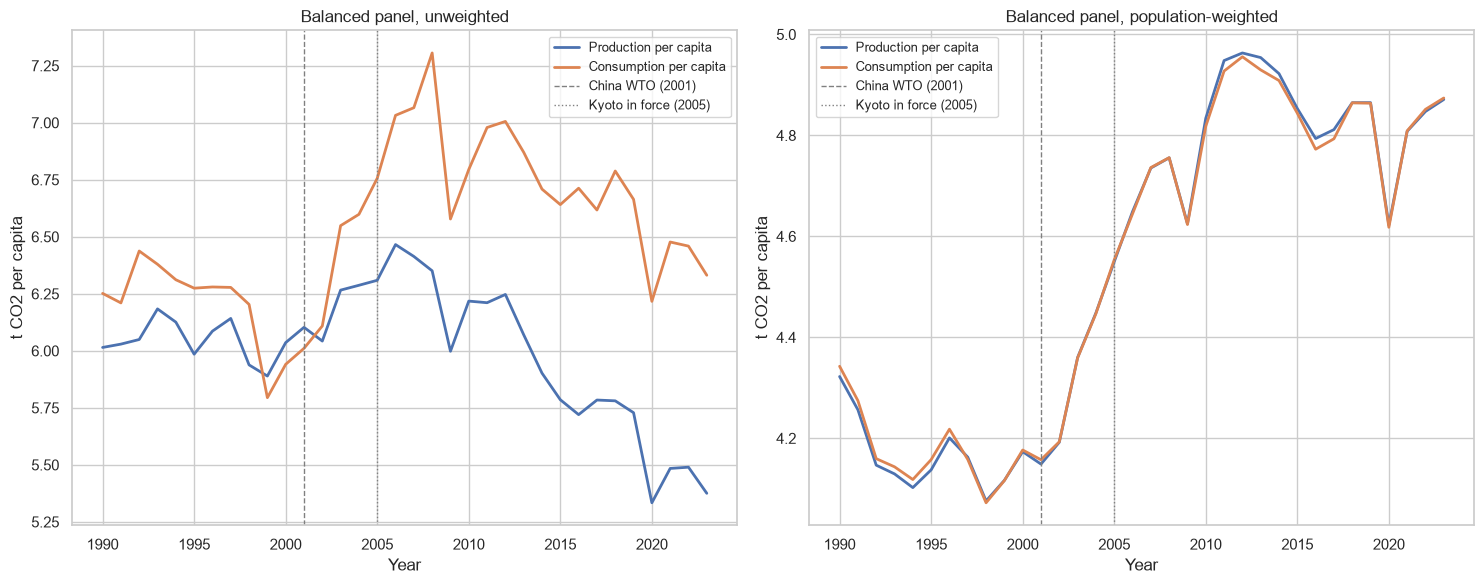

In [127]:
n_years = df['Year'].nunique()
full_coverage = df.groupby('ISO3')['Year'].nunique().loc[lambda s: s == n_years].index
balanced = df[df['ISO3'].isin(full_coverage)]
print(f'Balanced panel: {len(full_coverage)} of {df.ISO3.nunique()} countries '
      f'(dropped {sorted(set(df.ISO3) - set(full_coverage))})')


def yearly_means(d, weighted=False):
    out = {}
    for col in ['Production_Emissions_pc', 'Consumption_Emissions_pc']:
        sub = d[d[col].notna()]
        if weighted:
            out[col] = sub.groupby('Year').apply(
                lambda g: np.average(g[col], weights=g['Population']), include_groups=False)
        else:
            out[col] = sub.groupby('Year')[col].mean()
    return pd.DataFrame(out)


variants = {'All countries, unweighted': yearly_means(df),
            'Balanced panel, unweighted': yearly_means(balanced),
            'All countries, population-weighted': yearly_means(df, weighted=True),
            'Balanced panel, population-weighted': yearly_means(balanced, weighted=True)}

print('\nConsumption minus production, t CO2 per capita:')
gaps = pd.DataFrame({k: v['Consumption_Emissions_pc'] - v['Production_Emissions_pc']
                     for k, v in variants.items()})
print(gaps.loc[[1990, 2000, 2004, 2010, 2023]].round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)
for ax, key in [(axes[0], 'Balanced panel, unweighted'),
                (axes[1], 'Balanced panel, population-weighted')]:
    t = variants[key]
    ax.plot(t.index, t['Production_Emissions_pc'], label='Production per capita', linewidth=2)
    ax.plot(t.index, t['Consumption_Emissions_pc'], label='Consumption per capita', linewidth=2)
    ax.axvline(2001, color='gray', linestyle='--', linewidth=1, label='China WTO (2001)')
    ax.axvline(2005, color='gray', linestyle=':', linewidth=1, label='Kyoto in force (2005)')
    ax.set_title(key)
    ax.set_xlabel('Year')
    ax.set_ylabel('t CO2 per capita')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Balancing changes nothing; weighting changes everything

**Consumption minus production, t CO₂ per capita:**

| Variant | 1990 | 2004 | 2023 |
|---|---|---|---|
| All countries, unweighted | +0.237 | +0.320 | **+0.958** |
| Balanced panel, unweighted | +0.237 | +0.311 | **+0.956** |
| All countries, population-weighted | +0.020 | −0.000 | **+0.004** |
| Balanced panel, population-weighted | +0.020 | −0.001 | **+0.003** |

*(Re-verified on the current data — the values are unchanged.)*

**The balanced-panel check clears Norway completely.** The gap in 2004 moves from +0.320 to +0.311 and the 2023 value is unchanged to three decimals. The composition concern raised in Section 1 was worth testing and is now resolved: the widening gap in Section 7 is not an artefact of countries entering the sample.

**Population weighting removes the trend almost entirely** — and this is the finding that must be understood before Section 7 is used as evidence. Weighted by population, the gap is +0.020 in 1990, zero in 2004 and +0.004 in 2023. There is no widening at all.

**This is not a contradiction, and it is not a reason to discard Section 7 — but it changes what that chart means.** Global consumption and production emissions are two accountings of the *same* physical emissions, so they must sum to the same world total. A population-weighted per-capita average is close to that world total divided by world population, and it therefore *cannot* show a systematic gap. The near-zero weighted line is a consistency check passing, not an absence of leakage.

What the unweighted line measures is different: the gap in the **typical country**, which grows because the panel contains many small, rich, net-importing economies and a few large net exporters. That is a real and relevant distributional fact — leakage is precisely about *which* countries emit, not about the world total — but it must be stated as such.

**The concrete implication:** Section 7's chart should be labelled "average country", never "the world", and the widening gap should be described as a growing *dispersion* between importing and exporting countries rather than a growing global imbalance. A leakage claim has to be built on the cross-country distribution, which is what `gap_share` and `transfer_pc` capture and what the DiD in Section 11 tests.